# Plot-level validation of Boreal Forest Height from ICESat-2
 -  Eurasia field plots 2003-2021
 -  NFI Plots  
 -  Meisner Plots in Siberia

Paul Montesano, PhD  
NASA Goddard Space Flight Center  
January 2024

In [1]:
library(sf)
library(fs)
library(tidyverse)
library(plyr)

Linking to GEOS 3.12.1, GDAL 3.8.5, PROJ 9.4.0; sf_use_s2() is TRUE

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
------------------------------------------------------------------------------

You have loaded plyr after dplyr - this is likely to cause problems.
If you need functions from both plyr and dplyr, please load plyr first, then dplyr:
library(plyr); library(dplyr)

------------------------------------------------------------------------------


Attaching package: ‘plyr’


The following objects are masked f

In [2]:
install.packages("terra")
library(terra)

Warning message in install.packages("terra"):
“installation of package ‘terra’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

terra 1.7.78


Attaching package: ‘terra’


The following object is masked from ‘package:tidyr’:

    extract




In [3]:
# install.packages("remotes")
# library(remotes)
# remotes::install_github('https://github.com/ropensci/rnaturalearthhires')
# library(rnaturalearthhires)

In [4]:
#install.packages("rnaturalearth")
library(rnaturalearth)

In [5]:
#install.packages("rnaturalearthdata")
library(rnaturalearthdata)


Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110




In [6]:
#install.packages("mapproj")
library(mapproj)

Loading required package: maps


Attaching package: ‘maps’


The following object is masked from ‘package:plyr’:

    ozone


The following object is masked from ‘package:purrr’:

    map




In [7]:
#install.packages("patchwork")
library(patchwork)


Attaching package: ‘patchwork’


The following object is masked from ‘package:terra’:

    area




In [8]:
source('/projects/code/3dsi/boreal_map_functions.R') 
#source('/home/pmontesa/code/3dsi/boreal_map_functions.R') 

[1] "MAAP"
[1] "MAAP"



Attaching package: ‘data.table’


The following object is masked from ‘package:terra’:

    shift


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘scales’


The following object is masked from ‘package:terra’:

    rescale


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [9]:
arc_root

[1] "/projects/my-public-bucket/databank/arc/"

#### Get some geo data for maps

In [10]:
# wwf_tte = st_read('/explore/nobackup/people/pmontesa/userfs02/arc/wwf_terr_ecos_taiga-tundra.shp')
# ggplot() + geom_sf(data=wwf_tte)
# st_write(wwf_tte, '/explore/nobackup/people/pmontesa/userfs02/arc/wwf_terr_ecos_taiga-tundra.gpkg')

In [11]:
#sib_rivers <- terra::vect(paste0(arc_root,'/siberia_rivers_v6.shp')) %>% st_as_sf()
sib_rivers <- st_read(paste0(arc_root,'/siberia_rivers_v6.shp')) %>% 
                                            mutate(centroid = st_centroid(geometry)) %>%
                                            mutate(lon_cent = st_coordinates(centroid)[,1], 
                                                   lat_cent = st_coordinates(centroid)[,2])%>%
                        mutate(continent = ifelse(lon_cent > -10, 'Eurasia', 'North America'))
head(sib_rivers %>% as.data.frame())

Reading layer `siberia_rivers_v6' from data source 
  `/projects/my-public-bucket/databank/arc/siberia_rivers_v6.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 86 features and 13 fields
Geometry type: MULTILINESTRING
Dimension:     XY, XYZ
Bounding box:  xmin: 59.70167 ymin: 52.31647 xmax: 118.0107 ymax: 75.79348
z_range:       zmin: 0 zmax: 0
Geodetic CRS:  WGS 84


st_as_s2(): dropping Z and/or M coordinate



,OBJECTID,OID_,Name,FolderPath,SymbolID,AltMode,Base,Clamped,Extruded,Snippet,PopupInfo,Shape_Leng,Shape_Le_1,geometry,centroid,lon_cent,lat_cent,continent
,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<MULTILINESTRING [°]>,<POINT [°]>,<dbl>,<dbl>,<chr>
1,1,0,Voyevolikan,Kotuy-upper-tribs.kml/Kotuy-upper-tribs,0,0,0,-1,0,NA,NA,4.0407655,4.0407655,MULTILINESTRING Z ((100.567...,POINT (100.9711 66.51005),100.97109,66.51005,Eurasia
2,2,0,NA,Kotuy-upper-tribs.kml/Kotuy-upper-tribs,0,0,0,-1,0,NA,NA,3.5086026,3.5086026,MULTILINESTRING Z ((100.676...,POINT (99.49054 66.98806),99.49054,66.98806,Eurasia
3,3,0,NA,Kotuy-upper-tribs.kml/Kotuy-upper-tribs,0,0,0,-1,0,NA,NA,1.1789248,1.1789248,MULTILINESTRING Z ((100.863...,POINT (100.6628 67.36524),100.66281,67.36524,Eurasia
4,4,0,NA,Kotuy-upper-tribs.kml/Kotuy-upper-tribs,0,0,0,-1,0,NA,NA,0.6282958,0.6282958,MULTILINESTRING Z ((100.939...,POINT (101.1581 67.11807),101.15811,67.11807,Eurasia
5,5,0,NA,Kotuy-upper-tribs.kml/Kotuy-upper-tribs,0,0,0,-1,0,NA,NA,0.3089000,0.3089000,MULTILINESTRING Z ((100.644...,POINT (100.7546 66.95426),100.75458,66.95426,Eurasia
6,6,0,NA,Kotuy-upper-tribs.kml/Kotuy-upper-tribs,0,0,0,-1,0,NA,NA,1.3553514,1.3553514,MULTILINESTRING Z ((98.9963...,POINT (98.58417 67.86553),98.58417,67.86553,Eurasia


In [12]:
#lakes = st_read(paste0(arc_root, 'natural_earth/10m_physical/ne_10m_lakes.shp')) 
lakes = ne_download(scale = 'medium', type = 'lakes', category = 'physical', returnclass = "sf", ) #%>% 
                        #                     mutate(centroid = st_centroid(geometry)) #%>%
                        #                     mutate(lon_cent = st_coordinates(centroid)[,1], 
                        #                            lat_cent = st_coordinates(centroid)[,2]) %>%
                        # mutate(continent = ifelse(lon_cent > -10, 'Eurasia', 'North America'))

Reading layer `ne_50m_lakes' from data source `/tmp/RtmphMFuiJ/ne_50m_lakes.shp' using driver `ESRI Shapefile'
Simple feature collection with 412 features and 39 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -165.8985 ymin: -50.62002 xmax: 176.0827 ymax: 81.94033
Geodetic CRS:  WGS 84


In [13]:
riv = ne_download(scale = 'medium', type = 'rivers_lake_centerlines', category = 'physical', returnclass = "sf")

        
riv = st_read(riv_10m_fn) %>% 
                        mutate(centroid = st_centroid(geometry)) %>%
                        mutate(lon_cent = st_coordinates(centroid)[,1], 
                               lat_cent = st_coordinates(centroid)[,2]) %>%
                        mutate(continent = ifelse(lon_cent > -10, 'Eurasia', 'North America'))
head(riv %>% as.data.frame())

Reading layer `ne_50m_rivers_lake_centerlines' from data source 
  `/tmp/RtmphMFuiJ/ne_50m_rivers_lake_centerlines.shp' using driver `ESRI Shapefile'
Simple feature collection with 478 features and 36 fields (with 1 geometry empty)
Geometry type: MULTILINESTRING
Dimension:     XY
Bounding box:  xmin: -165.2439 ymin: -50.24014 xmax: 176.3258 ymax: 73.3349
Geodetic CRS:  WGS 84
Reading layer `ne_10m_rivers_lake_centerlines' from data source 
  `/projects/my-public-bucket/databank/arc/natural_earth/10m_physical/ne_10m_rivers_lake_centerlines.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1404 features and 7 fields
Geometry type: MULTILINESTRING
Dimension:     XY
Bounding box:  xmin: -164.9035 ymin: -52.15773 xmax: 177.2112 ymax: 75.79348
Geodetic CRS:  WGS 84


,dissolve,scalerank,featurecla,name,name_alt,rivernum,note,geometry,centroid,lon_cent,lat_cent,continent
,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<MULTILINESTRING [°]>,<POINT [°]>,<dbl>,<dbl>,<chr>
1,0River,1,River,Irrawaddy Delta,NA,0,NA,MULTILINESTRING ((95.4511 1...,POINT (95.35462 17.04341),95.35462,17.04341,Eurasia
2,1000Lake Centerline,9,Lake Centerline,Waiau,NA,1000,NA,MULTILINESTRING ((167.6473 ...,POINT (167.6369 -45.51862),167.63693,-45.51862,Eurasia
3,1000River,9,River,Waiau,NA,1000,NA,MULTILINESTRING ((167.734 -...,POINT (167.7147 -45.82327),167.71469,-45.82327,Eurasia
4,1001Lake Centerline,9,Lake Centerline,Tonle Sap,NA,1001,NA,MULTILINESTRING ((103.6874 ...,POINT (104.16 12.79591),104.15998,12.79591,Eurasia
5,1001River,9,River,Tonle Sap,NA,1001,NA,MULTILINESTRING ((104.6148 ...,POINT (104.7961 12.01493),104.79608,12.01493,Eurasia
6,1002Lake Centerline,9,Lake Centerline,NA,NA,1002,NA,MULTILINESTRING ((37.73951 ...,POINT (38.12492 59.12348),38.12492,59.12348,Eurasia


In [14]:
boreal = st_read(paste0(arc_root, '/wwf_circumboreal_Dissolve.gpkg')) %>% 
                        mutate(continent = ifelse(REALM == 'PA', 'Eurasia', 'North America'))
head(boreal %>% as.data.frame())

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.gpkg' 
  using driver `GPKG'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


,OBJECTID,REALM,Shape_Leng,Shape_Area,geom,continent
,<dbl>,<chr>,<dbl>,<dbl>,<MULTIPOLYGON [m]>,<chr>
1,1,NA,89451986,6.536703e+12,MULTIPOLYGON (((2314818 190...,North America
2,2,PA,138673973,1.254836e+13,MULTIPOLYGON (((-4053467 33...,Eurasia


## Get the plots with extracted 30m Vegetaion Height from ABoVE 
c2020 from ICESat-2 v005, Copernicus GLO30, HLS L30  
2020 from ICESat-2 v006, Copernicus GLO30, HLS H30  
this version of the map will be re-run with an updated global/local balance, but not likely to change much for the tiles associated with these plots

In [105]:
# I need a better way of indicating version
VAL_YEAR = 2020
VERSION = 'ht_H30'
VERSION_NUM = 'v2.0' #w/ moss/licen mask - just HLS
VARS_RS = 'ICESat-2 ATL08 v6 | Copernicus GLO30 | HLS H30'
TITLE_MAIN = paste0('Pixel-scale validation of predicted ',VERSION_NUM,' ',VAL_YEAR,' boreal vegetation height')
#VAL_TYPE = 'value_ht_L30_2020'
VAL_TYPE_1 = paste0('value_',VERSION,'_',VAL_YEAR)
VAL_TYPE_1

[1] "value_ht_H30_2020"

In [15]:
# I need a better way of indicating version
VAL_YEAR = 2020
VERSION = 'ht_S1H30'
VERSION_NUM = 'v2.2' #w/0 moss/licen mask - HLS and S1
VARS_RS = 'ICESat-2 ATL08 v6 | Copernicus GLO30 | HLS H30 | Sentinel-1'
TITLE_MAIN = paste0('Pixel-scale validation of predicted ',VERSION_NUM,' ',VAL_YEAR,' boreal vegetation height')
#VAL_TYPE = 'value_ht_L30_2020'
VAL_TYPE_2 = paste0('value_',VERSION,'_',VAL_YEAR)
VAL_TYPE_2

[1] "value_ht_S1H30_2020"

#### Ground plots
Lorey's Height: https://arbor-analytics.com/post/2023-04-21-lorey-s-height-the-remote-sensing-way-to-estimate-tree-height/  

*Metadata*:  
Eurasia - Miesner et al 2022 https://doi.org/10.5194/essd-14-5695-2022  
Eurasia - NASA plots  
N. America - Canadian NFI https://open.canada.ca/data/en/dataset/35c3556c-e48d-41a7-ac50-652257b0a8e8

In [16]:
# meisner_df = st_read('/projects/my-public-bucket/databank/extract_from_points/Miesner_plots_s3_esa_agb_age_ht.gpkg')
# nasa_df =    st_read('/projects/my-public-bucket/reference/extracted/eurasia_forest_structure_plots_smrytrees_20240124_s3_esa_agb_age_ht.gpkg')
# nfi_df =     st_read('/projects/my-public-bucket/databank/extract_from_points/nfi_plus_20220603_s3_esa_agb_age_ht.gpkg')

#### Find the latest extractions run in `Extract_TCC_from_points_AWS.ipynb`

In [17]:
path_extracted = '/projects/my-private-bucket/reference/extracted'
path_extracted = '/explore/nobackup/people/pmontesa/userfs02/data/reference/extracted'
path_extracted = '/projects/my-public-bucket/databank/extract_from_points'

In [47]:
# meisner_df = st_read(path(path_extracted, paste0('Miesner_plots_',VAL_TYPE,'.gpkg'))) %>% st_transform(4326)
# nasa_df =    st_read(path(path_extracted, paste0('eurasia_forest_structure_plots_smrytrees_20240124_',VAL_TYPE,'.gpkg'))) %>% st_transform(4326)
# nfi_df =     st_read(path(path_extracted, paste0('nfi_plus_20220603_',VAL_TYPE,'.gpkg'))) %>% st_transform(4326)

In [44]:
# Note extraction date in string of search pattern
files <- list.files(path_extracted, pattern = '*wGlobalCHM_s3_20241212.gpkg')

In [48]:
print(files)

[1] "eurasia_forest_structure_plots_smrytrees_20240124_s3_20241003_wGlobalCHM_s3_20241212.gpkg"
[2] "Miesner_plots_wGlobalCHM_s3_20241212.gpkg"                                                
[3] "nfi_plus_20220603_s3_20241003_wGlobalCHM_s3_20241212.gpkg"                                


In [206]:
for(f in files){
    if(grepl('nfi', f, fixed = TRUE)){
        nfi_df = st_read(path(path_extracted, f)) %>% st_transform(4326)}
    if(grepl('eurasia_forest_structure', f, fixed = TRUE)){
        nasa_df = st_read(path(path_extracted, f)) %>% st_transform(4326)}
    if(grepl('Miesner', f, fixed = TRUE)){
        meisner_df = st_read(path(path_extracted, f)) %>% st_transform(4326)}
}

Reading layer `eurasia_forest_structure_plots_smrytrees_20240124_s3_20241003_wGlobalCHM_s3_20241212' from data source `/projects/my-public-bucket/databank/extract_from_points/eurasia_forest_structure_plots_smrytrees_20240124_s3_20241003_wGlobalCHM_s3_20241212.gpkg' 
  using driver `GPKG'
Simple feature collection with 646 features and 45 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 85.78586 ymin: 42.0717 xmax: 138.5927 ymax: 72.409
Geodetic CRS:  WGS 84
Reading layer `Miesner_plots_wGlobalCHM_s3_20241212' from data source 
  `/projects/my-public-bucket/databank/extract_from_points/Miesner_plots_wGlobalCHM_s3_20241212.gpkg' 
  using driver `GPKG'
Simple feature collection with 226 features and 58 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 97.7064 ymin: 59.97058 xmax: 168.714 ymax: 72.54884
Geodetic CRS:  WGS 84
Reading layer `nfi_plus_20220603_s3_20241003_wGlobalCHM_s3_20241212' from data source `/projects/my-public-bucket/databank/extract_f

## Harmonize Reference Height
Prep individual data frames by specifying the various reference heights from each input  

Canadian NFI = Lorey's Height, else Site Height  
Miesner : 98th percentile Height  
NASA : median plot Height

### Clean

In [176]:
meisner_df_ = meisner_df %>% 
    separate(Campaign, sep='_', into=c('cont', 'year','group_name'), remove=FALSE) %>%
    mutate(continent = 'Eurasia', source = 'Miesner') 

nasa_df_ = nasa_df %>% 
    mutate(continent = 'Eurasia', source = 'NASA')%>%
    select(-value_meta_alsgedi_global_v6) # special drop - this data is now in value_ht_meta....

nfi_df_ = nfi_df %>% 
    separate(meas_date_x, sep='-', into=c('year')) %>%
    dplyr::select(ecozone, year, site_height, lorey_height, stem_density_standlive, 
                  contains("value_")
                #all_of(VAL_TYPE_1),
                #all_of(VAL_TYPE_2),
                #value_esawc2020,  value_standage2020
                   #value_AGB_L30_2020.v2023.local
          ) %>% 
    mutate(ref_ht = case_when(
            is.na(lorey_height) ~ site_height,
            .default = lorey_height
            )) %>%
    mutate(continent = 'North America', source = 'NFI') %>%
    select(-value_meta_alsgedi_global_v6) # special drop - this data is now in value_ht_meta....

# A couple Inf and -Inf values
nasa_df_[which(is.infinite(nasa_df_$Ht_max)), ] <- NA

Warning message:
“Expected 3 pieces. Additional pieces discarded in 7 rows [130, 132, 133, 134,
135, 136, 137].”
Warning message:
“Expected 1 pieces. Additional pieces discarded in 987 rows [1, 2, 3, 4, 5, 6,
7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”


In [208]:
colnames(meisner_df_)

[1] "index"                                  
 [2] "system.index"                           
 [3] "Area..Camp.Location."                   
 [4] "Area..District."                        
 [5] "Area..Federation.Subject."              
 [6] "Area..m..2."                            
 [7] "Campaign"                               
 [8] "cont"                                   
 [9] "year"                                   
[10] "group_name"                             
[11] "Comment..Area.comment."                 
[12] "Date.Time"                              
[13] "Elevation..m.asl."                      
[14] "Forest.type"                            
[15] "Genus..Most.frequent.species.group."    
[16] "Gini.coeff..Height."                    
[17] "H."                                     
[18] "Height.max..m."                         
[19] "Height.quantile..m...Quantile..25th.."  
[20] "Height.quantile..m...Quantile..75th.."  
[21] "Height.quantile..m...Quantile..90th.."  
[22] "Height.quantile..m...Quantile..98th.."  
[23] "PI"                                     
[24] "Plot..Area.seedlings.in.m."             
[25] "Plot..Area.shape.in.m."                 
[26] "Reference"                              
[27] "Site"                                   
[28] "Spec.No...."                            
[29] "Tree.BA..m..2.ha."                      
[30] "Tree.BA..m..2.ha...Living."             
[31] "Tree.BA.base..m..2."                    
[32] "Tree.BA.breast..m..2."                  
[33] "Tree.BA.breast..m..2...Living."         
[34] "Tree.height..m...Living..Mean.values."  
[35] "Tree.height..m...Living..Median.values."
[36] "Tree.height..m...Mean.values."          
[37] "Tree.height..m...Median.values."        
[38] "Tree.vol.conical..m..3.ha."             
[39] "Tree.vol.conical..m..3.ha...Living."    
[40] "Tree.vol.conical..m..3."                
[41] "Tree.vol.conical..m..3...Living."       
[42] "Tree.vol.smallian..m..3.ha."            
[43] "Tree.vol.smallian..m..3.ha...Living."   
[44] "Tree.vol.smallian..m..3."               
[45] "Tree.vol.smallian..m..3...Living."      
[46] "Trees....ha."                           
[47] "Trees...."                              
[48] "Trees......Living."                     
[49] "value_ht_lang_2022_10m_p98"             
[50] "value_ht_meta_alsgedi_global_v6_p50"    
[51] "value_ht_meta_alsgedi_global_v6_p95"    
[52] "value_ht_meta_alsgedi_global_v6_p98"    
[53] "value_ht_potapov_2021_30m_p95"          
[54] "value_ht_potapov_boreal_2021_30m_p95"   
[55] "X.Event"                                
[56] ".geo"                                   
[57] "index1"                                 
[58] "value_esawc2020"                        
[59] "value_standage2020"                     
[60] "value_ht_H30_2020"                      
[61] "value_ht_S1H30_2020"                    
[62] "geom"                                   
[63] "continent"                              
[64] "source"                                 
[65] "ref_ht"                                 
[66] "ref_ht_alpha"

### Set reference heights

In [209]:
# Meisner
meisner_df_$ref_ht = meisner_df_$Height.quantile..m...Quantile..98th..
##meisner_df$ref_ht = meisner_df$Tree.height..m...Median.values.

# NASA
nasa_df_$ref_ht = nasa_df_$Ht_med
#chk_df$ref_ht = chk_df$Ht_med

#nfi_df = nfi_df %>% mutate(ref_ht = mean(site_height , lorey_height, na.rm=TRUE))

# Set reference alphas to a measure of # trees in plot
meisner_df_$ref_ht_alpha = meisner_df_$Trees......Living.
nasa_df_$ref_ht_alpha = nasa_df_$N_ht
#chk_df$ref_ht_alpha = chk_df$N_ht
nfi_df_$ref_ht_alpha = nfi_df_$stem_density_standlive

nfi_df_$group_name = nfi_df_$ecozone

In [210]:
val_plots_df = rbind(meisner_df_ %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_")),
                     nasa_df_    %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_")),
                     nfi_df_     %>% select(geom, source, continent, group_name, year, ref_ht, ref_ht_alpha, contains("value_"))
                    #chk_df %>% select(geom, group_name, year, ref_ht, ref_ht_alpha, value_ht_L30_2020, value_esawc2020)
                    ) %>%
                mutate(source = factor(source)) %>%
                ## Replace NaN with 0 in ref_ht
                #mutate(ref_ht = ifelse(is.na(ref_ht), 0, ref_ht)) %>% 
                # Clean pred ht: set neg to NaN, then filter out NaN
                mutate(!!VAL_TYPE_1 := ifelse(!!VAL_TYPE_1 < 0, -1, !!VAL_TYPE_1)) %>% 
                filter(!is.na(ref_ht)) %>%
                filter(!is.na(!!VAL_TYPE_1)) %>% 
                # Remove empty geoms
                filter(!st_is_empty(.)) %>%
                mutate(diff_ht = get(VAL_TYPE_1) - ref_ht) %>%
                mutate(diff_yr = 2020 - as.numeric(year)) # Need to figure out how to use VAL_YEAR here
                
#val_plots_df = val_plots_df %>% drop_na() # If there are a lot of NA values then you want to go back to your Ht_H30_2020 and see which tiles are missing...

In [211]:
dim(val_plots_df)

[1] 1613   19

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


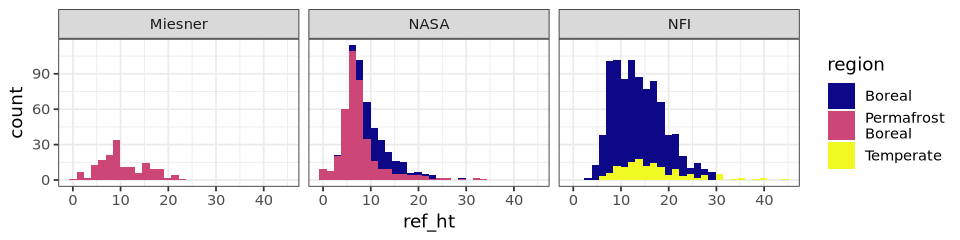

In [203]:
options(repr.plot.width = 8, repr.plot.height = 2)

# Set regions
val_plots_df = val_plots_df %>% 
                mutate(region = case_match(
                                    continent, c('Eurasia') ~ 'Permafrost\nBoreal',
                                               c('North America') ~ 'Boreal'

                ) ) %>%
                mutate(region = case_match( 
                                    group_name, 
                                        c('West Siberian Plains', 'Bahkta River','Tunguska River','Tahe','Russian Far East') ~ 'Boreal', 
                                       # (continent == 'North America' ~ 'Boreal') & (group_name != 'Atlantic Maritime' & group_name != 'Pacific Maritime' & group_name != 'Mixedwood Plains') ~ 'Boreal',
                                        c('Atlantic Maritime','Pacific Maritime','Mixedwood Plains') ~ 'Temperate',
                                    .default = region               
                                  )
                       )

#dim(val_plots_df %>% filter(continent != 'North America'))
#tail(val_plots_df %>% as.data.frame())
#ggplot() + geom_sf(data=ne_countries(scale = 10, returnclass = 'sf')) + geom_sf(data=val_plots_df, aes(color=region), size=1, alpha=0.25) + coord_sf(ylim=c(43.5,72.5))
ggplot() + geom_histogram(data=val_plots_df, aes(x=ref_ht, fill=region)) + facet_wrap(source ~., ncol=3) + theme_bw() + scale_fill_viridis_d(option=6)

In [205]:
st_write(obj = val_plots_df, dsn = path(path_extracted, 'boreal_height_val_plots_cleaned.gpkg'))

Writing layer `boreal_height_val_plots_cleaned' to data source 
  `/projects/my-public-bucket/databank/extract_from_points/boreal_height_val_plots_cleaned.gpkg' using driver `GPKG'
Writing 1613 features with 19 fields and geometry type Point.


# Map plots with labels

try and fix label placement:  
https://yutannihilation.github.io/ggsflabel/reference/geom_sf_label.html

## Map all plots

In [70]:
install.packages('devtools')

also installing the dependencies ‘credentials’, ‘gitcreds’, ‘ini’, ‘curl’, ‘diffobj’, ‘gert’, ‘gh’, ‘rprojroot’, ‘whisker’, ‘downlit’, ‘httr2’, ‘xopen’, ‘brew’, ‘brio’, ‘evaluate’, ‘praise’, ‘waldo’, ‘withr’, ‘usethis’, ‘desc’, ‘miniUI’, ‘pkgbuild’, ‘pkgdown’, ‘pkgload’, ‘profvis’, ‘rcmdcheck’, ‘remotes’, ‘roxygen2’, ‘rversions’, ‘sessioninfo’, ‘testthat’, ‘urlchecker’


Warning message in install.packages("devtools"):
“installation of package ‘curl’ had non-zero exit status”
Warning message in install.packages("devtools"):
“installation of package ‘diffobj’ had non-zero exit status”
Warning message in install.packages("devtools"):
“installation of package ‘brio’ had non-zero exit status”
Warning message in install.packages("devtools"):
“installation of package ‘profvis’ had non-zero exit status”
Warning message in install.packages("devtools"):
“installation of package ‘downlit’ had non-zero exit status”
Warning message in install.packages("devtools"):
“installation of package ‘httr2’ 

In [75]:
#devtools::install_github("ropensci/rnaturalearthhires")

In [74]:
library(rnaturalearth)

In [80]:
worldmap = ne_countries(scale = 'medium', returnclass = 'sf') #%>% filter(continent %in% CONTINENT_LIST) %>% mutate(continent = ifelse(continent == 'North America','North America',ifelse(continent == 'Europe','Eurasia',ifelse(continent == 'Asia','Eurasia','other'))))


In [81]:
MAP_PLOTS <- function(val_plots_df, XLIMS, YLIMS, CONTINENT_LIST=c('North America','Eurasia','Europe','Asia'), MAP_VERSION=paste(VERSION, VAL_YEAR, sep=' ')){
    
    if(CONTINENT_LIST != 'None'){
        #val_plots_df = val_plots_df %>% filter(`continent` == CONTINENT)
        val_plots_df = val_plots_df %>% filter(`continent` %in% CONTINENT_LIST)
        }
    
    smry_plots_df = val_plots_df %>%
                #drop_na() %>%
                dplyr::group_by(group_name, year, continent) %>%
                dplyr::summarise(st_union(geom), n=n(), RMSD = sqrt(mean(diff_ht*diff_ht))) %>%
                st_centroid() %>%
                tidyr::unite("group_year", group_name:year, sep = ": ", remove = FALSE) %>% 
                tidyr::unite("group_year_n", c(group_year, n), sep = " ", remove = FALSE) %>% 
                st_jitter(0.5, factor = 0.2)
    
    worldmap = ne_countries(scale = 'medium', returnclass = 'sf') #%>% filter(continent %in% CONTINENT_LIST) %>% mutate(continent = ifelse(continent == 'North America','North America',ifelse(continent == 'Europe','Eurasia',ifelse(continent == 'Asia','Eurasia','other'))))
    
    basemaps_list = list(
        geom_sf(data=worldmap),
        geom_sf(data=boreal, alpha=0.5, fill='gray', color=NA),
        geom_sf(data=sib_rivers, color='white', size=0.01), 
        geom_sf(data=riv, color='white', size=0.01),
        geom_sf(data=lakes, fill='white', color='white', size=0.01),
        geom_sf(data=worldmap, fill=NA, color='black', size=0.001)
        )
    maps_style_list = list(
        #scale_fill_viridis_d(option='plasma', name='Year of plot obs.',aesthetics = c("colour", "fill")),
        scale_fill_viridis_c(option='plasma', name='Decade of plot obs.',aesthetics = c("colour", "fill"), limits = c(1990, 2025), oob = scales::squish),
        scale_size_continuous(guide=FALSE),
        theme_bw(),
        guides(fill=guide_legend(title.position = "top", label.position = "bottom", legend.position='horizontal', nrow=1),
               color=guide_legend(title.position = "top", label.position = "bottom", legend.position='horizontal', nrow=1)),
        theme(text = element_text(size=16), legend.position = c(0.9, 0.85) ),
        theme(legend.background = element_rect(colour = 'black', fill = 'white', linetype='solid')),
        coord_sf(xlim = XLIMS, ylim = YLIMS, expand = FALSE),
        theme(legend.position="bottom"),
        labs(
            #title=paste0(CONTINENT, ' field validation plots'), 
            x=NULL, y=NULL, caption=paste0("Plots, n=", sum(smry_plots_df$n), ' | Version: ', MAP_VERSION)
        ) #,
        #facet_wrap(continent~.)
    )
       
    map_inset_region = ggplot() +
        list(geom_sf(data=worldmap),
        geom_sf(data=boreal, alpha=0.5, fill='gray', color=NA),
        geom_sf(data=worldmap, fill=NA, color='black', size=0.001)
             ) +
        geom_sf(data=val_plots_df %>% drop_na() , aes(color=region), size=0.25) +
        coord_sf(xlim = XLIMS, ylim = YLIMS, expand = FALSE) +
        scale_color_brewer(palette='Set1', name=NULL) +
        theme(
        axis.text = element_blank(),
        legend.position='bottom', 
        legend.direction='horizontal'
    )
    #print(map_inset_region)
    
    map_plots_option1 = ggplot() + 
        basemaps_list +
        # # Size labels with n
        #geom_sf_label(data=smry_plots_df, aes(label=group_year, size=n), vjust=0, hjust=0, nudge_x = 1) + 
        geom_sf_label(data=smry_plots_df, aes(label=group_year), vjust=0, hjust=0, size=2, position=position_jitter(width=3,height=0)) + 
        # Option 1 for points
        geom_sf(data=val_plots_df %>% drop_na(), aes(color=factor(year)), shape=21, size=4) +
        geom_sf(data=val_plots_df %>% drop_na(), shape=19, size=1, alpha=0.1) +
        maps_style_list
    
    map_plots_option2 = ggplot() + 
        basemaps_list +
        # # Size labels with n
        #geom_sf_label(data=smry_plots_df, aes(label=group_year, size=n), vjust=0, hjust=0, nudge_x = 1) + 
        #geom_sf_label(data=smry_plots_df, aes(label=group_year), vjust=0, hjust=0, size=2, position=position_jitter(width=3,height=0)) + 
        # Option 2 for points
        geom_sf(data=val_plots_df %>% drop_na() , aes(fill=as.numeric(year)), shape=21, size=4, color='black') +
        maps_style_list
    
    map_plots_option3 = ggplot() + 
        basemaps_list +
        geom_sf(data=smry_plots_df, aes(fill=factor(year), size=n), shape=21, alpha=0.25, show.legend=TRUE) +
        maps_style_list +
        scale_size(range = c(10, 25))
    
    map_final = map_plots_option2 #+ inset_element(map_inset_region, left = 0, bottom = 0.0, right = 0.25, top = 0.25 ) & theme(panel.border = element_rect(colour = "black", fill=NA))

    #print(map_plots_option1)
    #print(map_plots_option2)
    #print(map_plots_option3)
    return(list(smry_plots_df, map_final))
    }

In [82]:
options(repr.plot.width = 12, repr.plot.height = 6)

XLIMS_EA = c(79, 180)
YLIMS_EA = c(47, 77)
r = MAP_PLOTS(val_plots_df, XLIMS_EA, YLIMS_EA, CONTINENT_LIST = c('Eurasia'))
m_eurasia = r[[2]]
m_eurasia

`summarise()` has grouped output by 'group_name', 'year'. You can override
using the `.groups` argument.


ERROR: Error in MAP_PLOTS(val_plots_df, XLIMS_EA, YLIMS_EA, CONTINENT_LIST = c("Eurasia")): object 'riv' not found


In [ ]:
options(repr.plot.width = 12, repr.plot.height = 6)
XLIMS_NA = c(-150, -45)
YLIMS_NA = c(42, 73)
r = MAP_PLOTS(val_plots_df, XLIMS_NA, YLIMS_NA, CONTINENT_LIST=c('North America'))
m_northamerica = r[[2]]

although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
although coordinates are longitude/latitude, st_union assumes that they are planar
alth

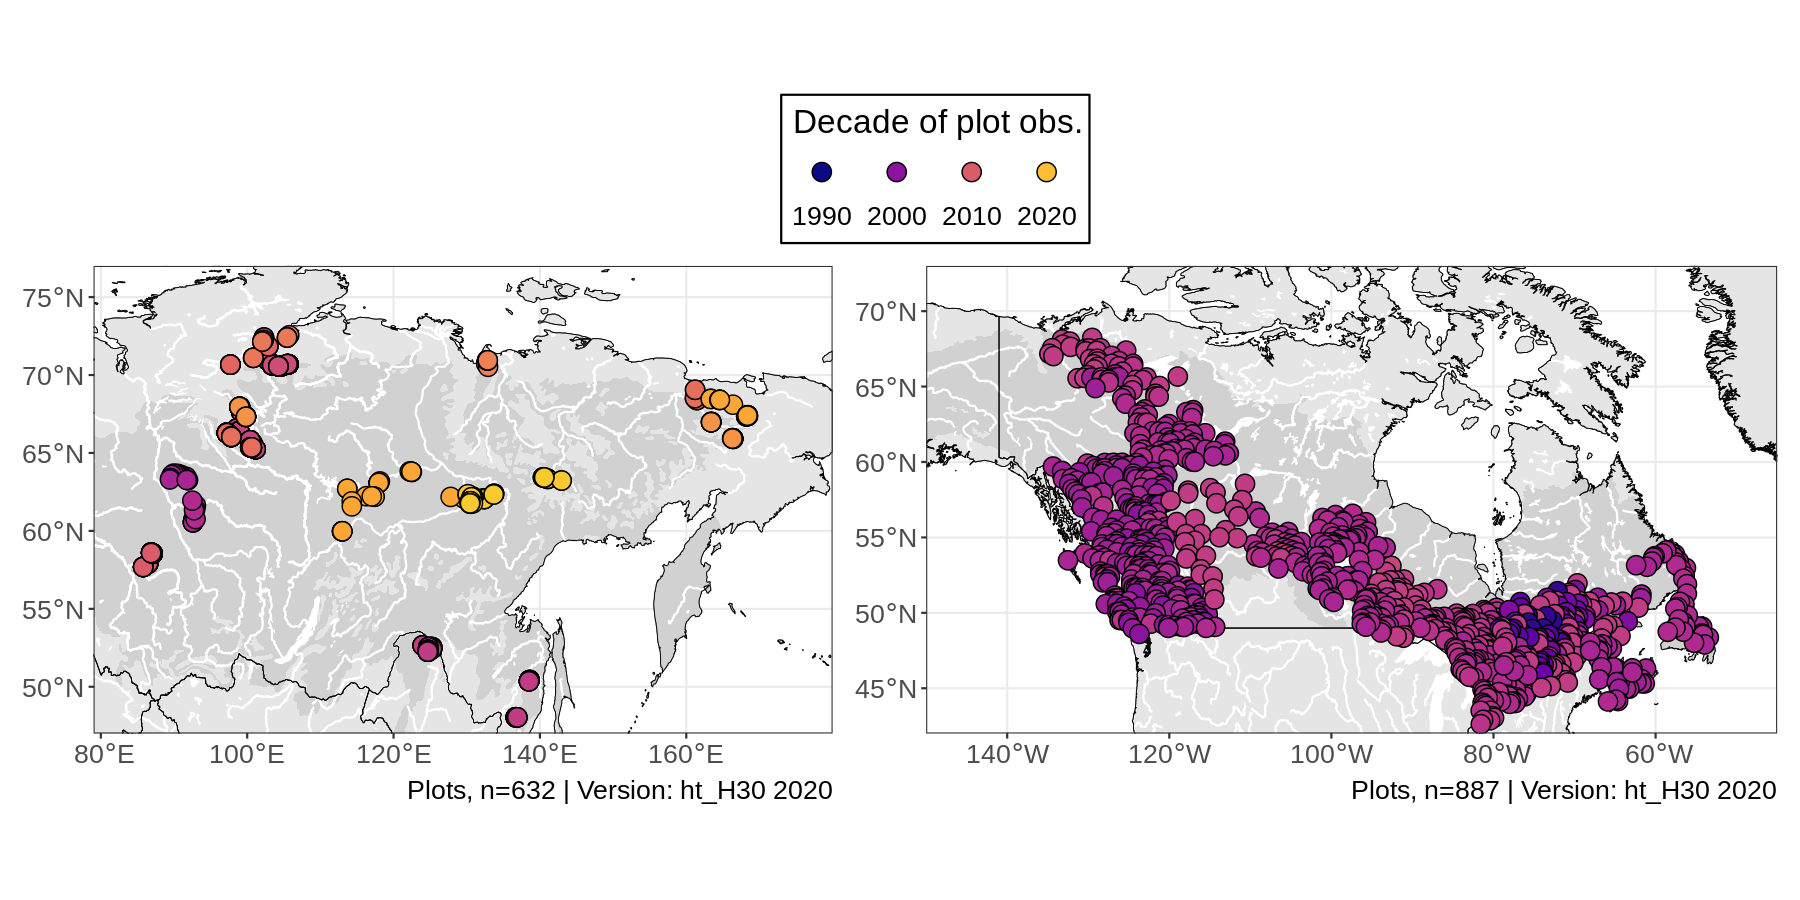

In [706]:
options(repr.plot.width = 12, repr.plot.height = 6)

maps_both = (m_eurasia + m_northamerica & theme(legend.position = 'top')) + plot_layout(guides = "collect")
maps_both

In [707]:
source('/home/pmontesa/code/3dsi/plot_functions.R') 

[1] "ADAPT, EXPLORE"


In [708]:
cols = c('int','slope','r2','rmsd','rmse','sig2','n','mae','mape','rrmse')

## Summarize: apply linear model by year, region, plot group name, and continent

Plot group name is either the field plot group (NASA, Meisner) or an ecozone (NFI)

In [937]:
MAX_DIFF_YR = 15
dim(val_plots_df %>% filter(diff_yr <= MAX_DIFF_YR))

[1] 851  11

### Plot group names
`Note`: some plot groups were collected over multiple years

In [954]:
print(levels(factor(val_plots_df$group_name)))

 [1] "Atlantic Maritime"    "Bakhta River"         "Boreal Cordillera"   
 [4] "Boreal Plains"        "Boreal Shield"        "Chukotka"            
 [7] "Embenchime River"     "Hudson Plains"        "Keperveem"           
[10] "Khatanga"             "Kochechum River"      "Kotuy River"         
[13] "Kotuykan River"       "Kytalyk"              "Mixedwood Plains"    
[16] "Montane Cordillera"   "Northernmost (AWI)"   "Omoloy"              
[19] "Pacific Maritime"     "Russian Far East"     "Tahe"                
[22] "Taiga Plains"         "Taymyr"               "Tunguska River"      
[25] "West Siberian Plains" "Yakutia"             


In [1018]:
str(val_plots_df)

Classes ‘sf’ and 'data.frame':	1519 obs. of  11 variables:
 $ source           : Factor w/ 3 levels "Miesner","NASA",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ continent        : chr  "Eurasia" "Eurasia" "Eurasia" "Eurasia" ...
 $ group_name       : chr  "Khatanga" "Khatanga" "Khatanga" "Khatanga" ...
 $ year             : chr  "2011" "2011" "2011" "2011" ...
 $ ref_ht           : num  7.58 9 10 11.92 5 ...
 $ ref_ht_alpha     : num  70 81 28 58 95 262 98 62 184 91 ...
 $ value_ht_H30_2020: num  5.264 1.602 5.771 6.187 0.745 ...
 $ geom             :sfc_POINT of length 1519; first list element:  'XY' num  102.9 71.8
 $ diff_ht          : num  -2.32 -7.4 -4.23 -5.73 -4.26 ...
 $ diff_yr          : num  9 9 9 9 9 9 9 9 8 8 ...
 $ region           : chr  "Permafrost\nBoreal" "Permafrost\nBoreal" "Permafrost\nBoreal" "Permafrost\nBoreal" ...
 - attr(*, "sf_column")= chr "geom"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA NA NA NA NA NA NA
  ..- attr(*, "names")= chr  "s

In [1028]:
df_eq_all <- ddply(val_plots_df %>% 
                            filter(diff_yr <= MAX_DIFF_YR) %>%
                            dplyr::select(one_of(VAL_TYPE), ref_ht, year, group_name, region, diff_yr, continent ), .(), c("lm_eqn") )
df_eq_all

.id,int,slope,r2,rmsd,rrmsd,rmse,rrmse,sig2,n,mae,mape
NA,3.03,0.73,0.4,4.65,0.47,4.44,0.44,19.78,851,3.48,60.84


In [1029]:
df_eq_region <- ddply(val_plots_df %>% 
                            filter(diff_yr <= MAX_DIFF_YR) %>%
                            dplyr::select(one_of(VAL_TYPE), ref_ht, year, group_name, region, diff_yr, continent ), .(region,continent), c("lm_eqn") )
df_eq_region

region,continent,int,slope,r2,rmsd,rrmsd,rmse,rrmse,sig2,n,mae,mape
Boreal,Eurasia,11.83,0.45,0.13,7.15,0.59,4.48,0.37,20.36,141,3.33,29.04
Boreal,North America,3.32,0.61,0.30,4.78,0.38,4.14,0.33,17.31,205,3.40,47.89
Permafrost Boreal,Eurasia,3.47,0.50,0.33,3.46,0.45,2.83,0.37,8.02,462,2.22,62.38
Temperate,North America,6.31,0.63,0.43,4.88,0.30,4.35,0.27,19.81,43,3.30,26.95


In [1030]:
df_eq_region_year <- ddply(val_plots_df %>% 
                            filter(diff_yr <= MAX_DIFF_YR) %>%
                            dplyr::select(one_of(VAL_TYPE), ref_ht, year, group_name, region, diff_yr, continent ), .(year, region,continent), c("lm_eqn") )
df_eq_region_year

year,region,continent,int,slope,r2,rmsd,rrmsd,rmse,rrmse,sig2,n,mae,mape
2005,Boreal,North America,1.81,0.81,0.51,3.35,0.28,3.22,0.27,10.64,80,2.70,32.94
2005,Temperate,North America,7.95,0.61,0.42,5.60,0.30,4.87,0.26,26.39,20,3.83,26.88
2006,Boreal,Eurasia,10.58,0.53,0.17,6.77,0.62,3.84,0.35,15.09,80,2.64,22.87
2006,Boreal,North America,3.65,0.54,0.24,5.52,0.43,4.50,0.35,20.62,124,3.67,54.73
2006,Temperate,North America,9.50,0.33,0.12,4.16,0.30,3.34,0.24,12.21,23,2.46,24.95
2007,Boreal,North America,11.31,NA,0.00,1.39,0.11,0.00,0.00,NaN,1,0.00,0.00
2007,Permafrost Boreal,Eurasia,9.79,-0.05,0.00,3.93,0.61,1.69,0.26,2.99,47,1.44,15.47
2008,Permafrost Boreal,Eurasia,4.19,0.26,0.03,2.05,0.31,1.69,0.26,2.93,96,1.36,27.34
2010,Boreal,Eurasia,14.74,0.28,0.04,7.61,0.56,5.10,0.37,26.90,61,3.98,36.15
2011,Permafrost Boreal,Eurasia,3.53,0.13,0.05,4.04,1.00,2.18,0.54,5.31,19,1.99,84.83


In [1031]:
df_eq_region_year_group <- ddply(val_plots_df %>% 
                            filter(diff_yr <= MAX_DIFF_YR) %>%
                            dplyr::select(one_of(VAL_TYPE), ref_ht, year, group_name, region, diff_yr, continent ), .(year, group_name, region,continent), c("lm_eqn") )

#df_eq_region_year_group[,cols] <- lapply(df_eq_region_year_group[,cols], function(x) as.numeric(as.character(x)))

df_eq_region_year_group

year,group_name,region,continent,int,slope,r2,rmsd,rrmsd,rmse,rrmse,sig2,n,mae,mape
2005,Boreal Cordillera,Boreal,North America,14.13,0.07,0.01,4.12,0.24,1.96,0.11,6.40,5,1.85,12.00
2005,Boreal Plains,Boreal,North America,21.51,NA,0.00,0.21,0.01,0.00,0.00,NaN,1,0.00,0.00
2005,Boreal Shield,Boreal,North America,7.39,0.43,0.18,3.00,0.24,2.54,0.20,6.75,45,2.01,17.75
2005,Mixedwood Plains,Temperate,North America,12.32,0.26,0.10,5.36,0.31,3.86,0.22,17.22,15,2.83,24.98
2005,Montane Cordillera,Boreal,North America,12.73,0.27,0.61,4.11,0.24,1.18,0.07,2.30,5,0.97,5.51
2005,Pacific Maritime,Temperate,North America,13.95,0.56,0.75,6.26,0.27,2.99,0.13,14.85,5,2.26,8.48
2005,Taiga Plains,Boreal,North America,5.80,0.06,0.00,3.67,0.46,3.09,0.39,10.42,24,2.30,38.23
2006,Atlantic Maritime,Temperate,North America,12.69,0.10,0.03,4.04,0.30,2.00,0.15,4.58,16,1.51,10.74
2006,Boreal Plains,Boreal,North America,9.42,0.16,0.02,7.63,0.51,5.72,0.38,34.86,32,4.89,59.86
2006,Boreal Shield,Boreal,North America,6.29,0.43,0.22,4.21,0.31,3.24,0.24,10.85,67,2.60,29.15


In [1032]:
smry_plot_groups = df_eq_region_year_group %>% group_by(region, continent) %>% dplyr::summarize(n_groups = n())
smry_plot_groups

`summarise()` has grouped output by 'region'. You can override using the
`.groups` argument.

region,continent,n_groups
Boreal,Eurasia,3
Boreal,North America,10
Permafrost Boreal,Eurasia,14
Temperate,North America,4


# Distribution of RMSE from each 'diff_yr' model for 2 regions

#### Is this most useful? Maybe this shows usefulness of separating the faster growing `Other Boreal` plots from the `Permafrost Larch`


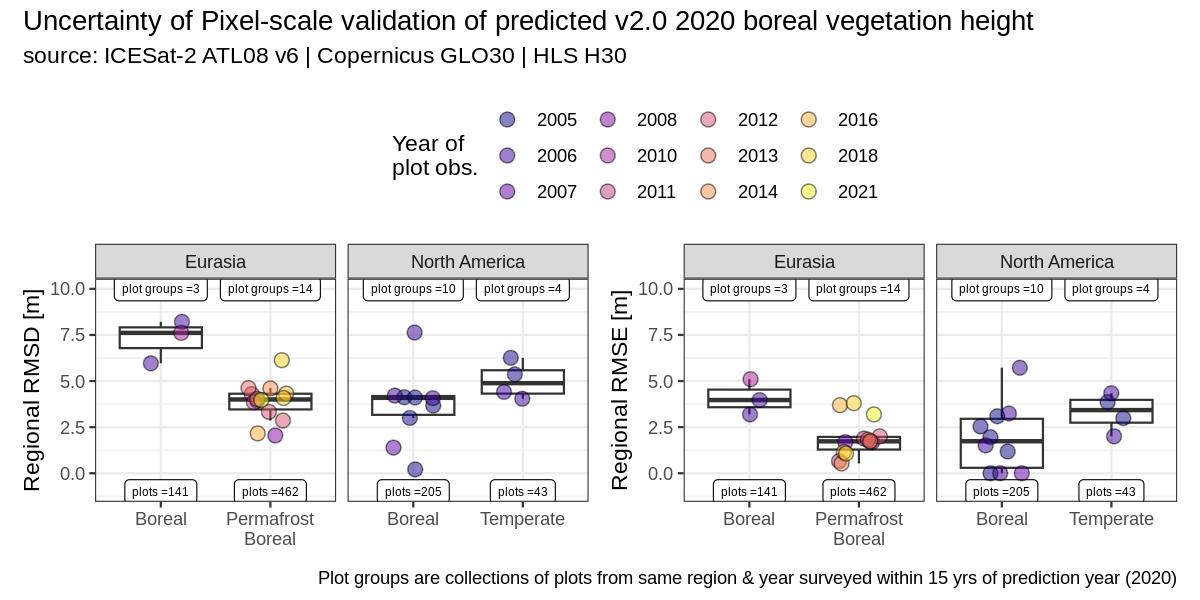

In [997]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 150)
htmax = 10
geom_boxplot_list = list(
        geom_boxplot(outlier.shape = NA) ,
        geom_label(data=smry_df_eq_region, aes(x=region, y=-1, label=paste("plots =", n_plots, sep='')), parse = FALSE, size=2, color = "black", fill="white", label.padding=unit(0.25,"lines") ),
        geom_label(data=smry_plot_groups, aes(x=region, y=htmax, label=paste("plot groups =", n_groups, sep='')), parse = FALSE, size=2, color = "black", fill="white", label.padding=unit(0.25,"lines") ),
        geom_jitter(aes(fill=year),width=0.2, height=0, shape=21, color='black', size=3, alpha=0.5)
    )
geom_viz_list = list(
    #scale_color_viridis_c(option='plasma', name='Difference (years)\nbetween plot obs.\n[satellite-field]') ,
    scale_fill_viridis_d(option='plasma', name='Year of\nplot obs.') ,
    #scale_fill_viridis_d(option='plasma', name='Decade of plot obs.', limits = c(1990, 2025)) ,
    coord_cartesian(ylim=c(-1,htmax)),
    theme_bw() ,
    facet_wrap(~continent, scales='free_x')
    )

p_rmsd = ggplot(df_eq_region_group #%>% drop_na()
                , aes(x=region, y=rmsd)) + 
    geom_boxplot_list +
    #labs(y=paste('Regional RMSD\nPredicted ',VAL_YEAR,' Boreal Height [m]'), x=NULL) +
    labs(y='Regional RMSD [m]', x=NULL) +
    geom_viz_list

p_rmse = ggplot(df_eq_region_group #%>% drop_na()
                , aes(x=region, y=rmse)) + 
    geom_boxplot_list +
    #labs(y=paste('Regional RMSE\nPredicted ',VAL_YEAR,' Boreal Height [m]'), x=NULL) +
    labs(y='Regional RMSE [m]', x=NULL) +
    geom_viz_list +
    theme(     
        legend.position='bottom', 
        legend.direction='horizontal'
    )

(p_rmsd + p_rmse & theme(legend.position = 'top')) + plot_layout(guides = "collect") +  plot_annotation(
  title = paste0('Uncertainty of ', TITLE_MAIN),
  subtitle = paste0('source: ', VARS_RS),
  caption = paste0('Plot groups are collections of plots from same region & year surveyed within ', MAX_DIFF_YR, ' yrs of prediction year (',VAL_YEAR,')' )
)

# Region-level models
#### Given the distribution of 'diff_yr' models grouped by region, the region-level models show a better relationship at the 30m pixel level for the permafrost larch plots (that whose diff_yr is less important because of slow growth).

In [994]:
df_eq_region

region,continent,int,slope,r2,rmsd,rrmsd,rmse,rrmse,sig2,n,mae,mape
Boreal,Eurasia,11.83,0.45,0.13,7.15,0.59,4.48,0.37,20.36,141,3.33,29.04
Boreal,North America,3.32,0.61,0.30,4.78,0.38,4.14,0.33,17.31,205,3.40,47.89
Permafrost Boreal,Eurasia,3.47,0.50,0.33,3.46,0.45,2.83,0.37,8.02,462,2.22,62.38
Temperate,North America,6.31,0.63,0.43,4.88,0.30,4.35,0.27,19.81,43,3.30,26.95


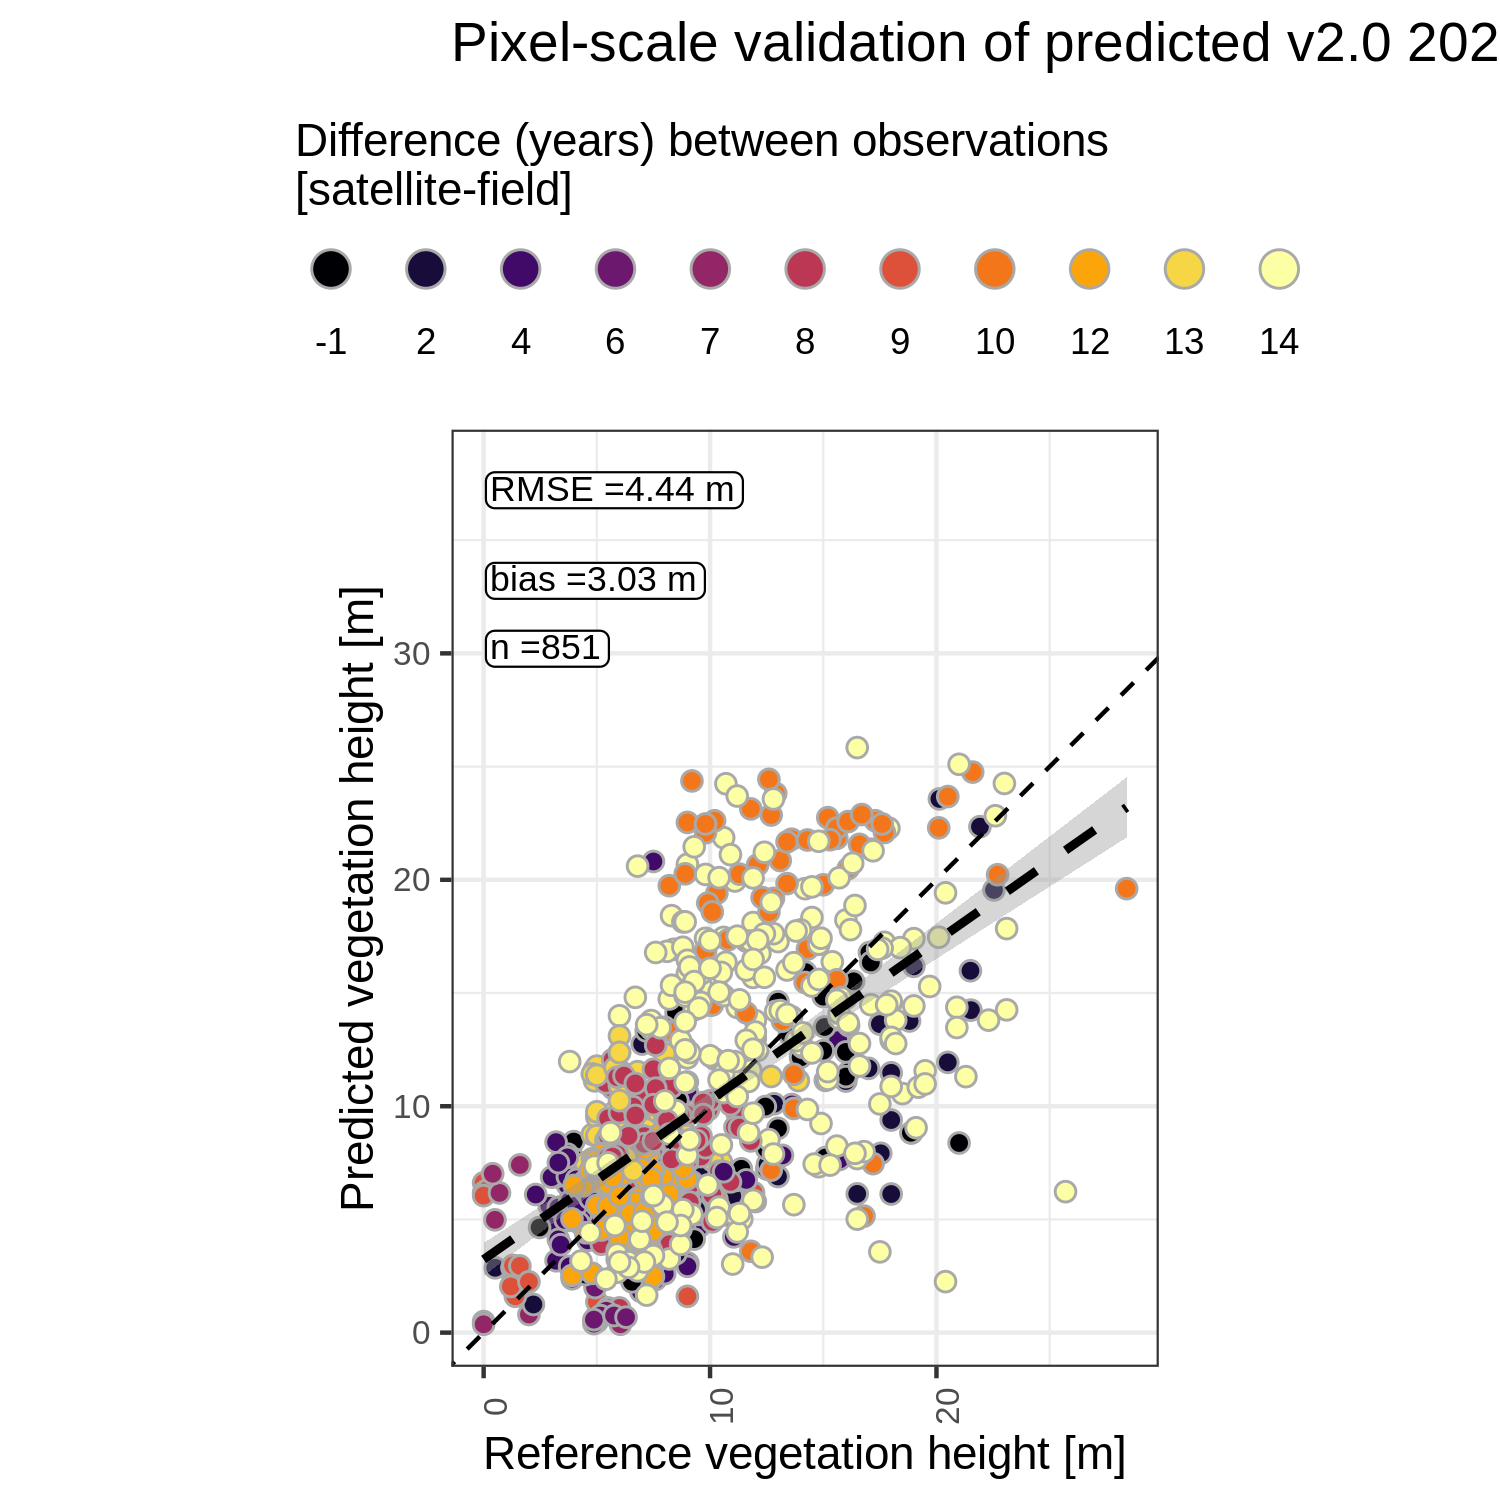

In [1038]:
options(repr.plot.width =5, repr.plot.height = 5, repr.plot.res = 300)

htmax = 40

p_scat_all = val_plots_df %>% 
    filter(diff_yr < MAX_DIFF_YR) %>%
    ggplot(aes(x=as.numeric(ref_ht), y=as.numeric(value_ht_H30_2020) )) + 
    geom_point(
        #aes(color=factor(value_esawc2020)), 
        aes(fill=factor(diff_yr)),
        size=2, alpha=1,
        shape=21,
        color='darkgrey'
    ) + 
    #scale_color_manual(values = c("#0072B2","#009E73","#D55E00")) +
    #scale_color_manual(values = col_pal, name='Land Cover Class') +
    scale_fill_viridis_d(option='inferno', name='Difference (years) between observations\n[satellite-field]') +
    geom_abline(linetype='dashed') +
    coord_equal() +
    theme_bw() +
    theme(axis.text.x=element_text(angle=90, size=8), axis.text.y = element_text(size=8), strip.text = element_text(size=7)) + 
    labs(x='Reference vegetation height [m]', y = 'Predicted vegetation height [m]', 
         #title='ABoVE Boreal Forest Height c.2020 (gridded, 30m)\nvalidation with boreal forest plots', subtitle='source: ICESat-2, Topography, & HLS L30') +
         #title='ABoVE Boreal Vegetation Height 2020 (gridded, 30m)\nvalidation with boreal forest plots', subtitle=paste0('source: ', VARS_RS)) +
         title=paste0(TITLE_MAIN)) +
    #facet_grid(region~continent)+
    #facet_wrap(.~continent+region, ncol=4)+
    #geom_label(data=df_eq_region, aes(x = 0.1, y = htmax,label=paste("r^2 ==", r2,sep='')), parse = TRUE, hjust="inward", vjust="inward", size=3, color = "black", fill="white", label.padding=unit(0.1,"lines"))+
    geom_label(data=df_eq_all, aes(x = 0.1, y = htmax-2,label=paste("RMSE =", rmse, " m", sep='')), parse = FALSE, hjust="inward", vjust="inward", size=3, color = "black", fill="white", label.padding=unit(0.1,"lines"))+
    geom_label(data=df_eq_all, aes(x = 0.1, y = htmax-6,label=paste("bias =", int, " m", sep='')),  parse = FALSE, hjust="inward", vjust="inward", size=3, color = "black", fill="white", label.padding=unit(0.1,"lines"))+
    geom_label(data=df_eq_all, aes(x = 0.1, y = htmax-9,label=paste("n =", n, sep='')),             parse = FALSE, hjust="inward", vjust="inward", size=3, color = "black", fill="white", label.padding=unit(0.1,"lines")) +
    guides(fill=guide_legend(override.aes = list(size = 4), title.position = "top", label.position = "bottom", legend.position='horizontal', nrow=1,
                                     #,keywidth = unit(.125, "cm"), keyheight = unit(1, "cm")
                                    )) +
    geom_smooth(method='lm', formula= y~x, color='black', linetype='dashed') +
    theme(legend.position='top', strip.text.x = element_text(size=10))

p_scat_all

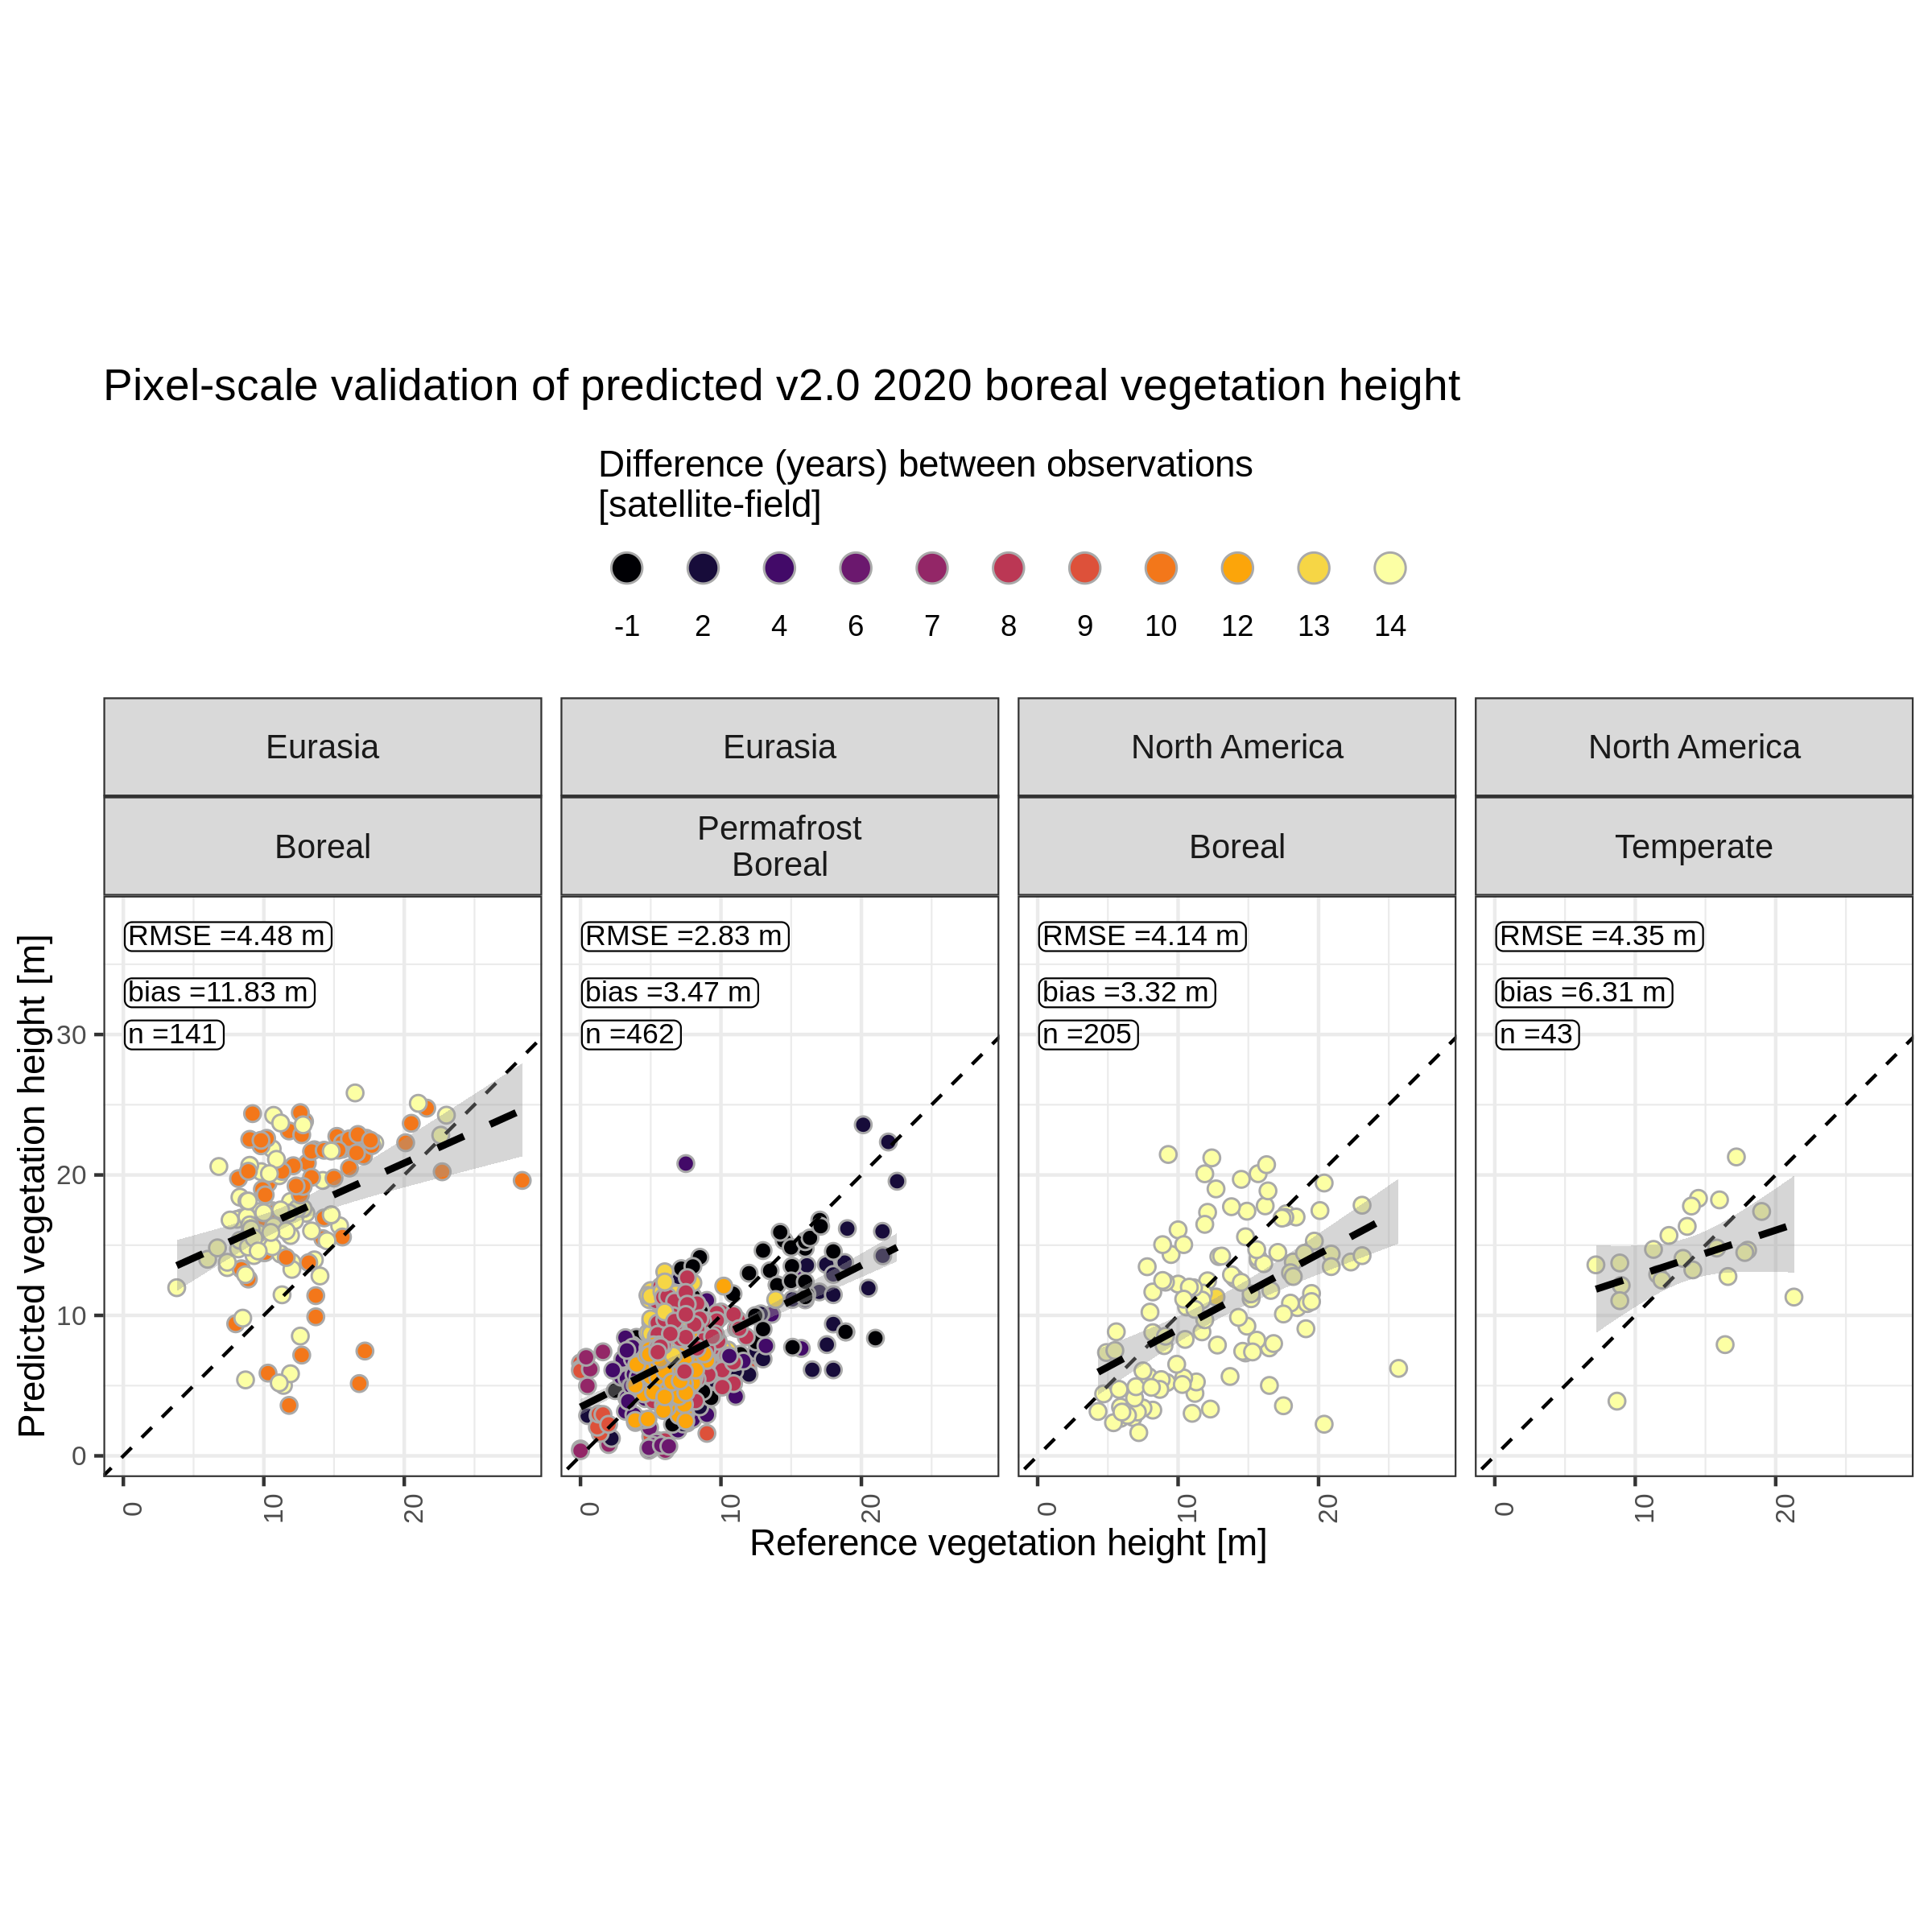

In [1005]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 300)

htmax = 40

p_scat_region = val_plots_df %>% 
    filter(diff_yr < MAX_DIFF_YR) %>%
    ggplot(aes(x=as.numeric(ref_ht), y=as.numeric(value_ht_H30_2020) )) + 
    geom_point(
        #aes(color=factor(value_esawc2020)), 
        aes(fill=factor(diff_yr)),
        size=2, alpha=1,
        shape=21,
        color='darkgrey'
    ) + 
    #scale_color_manual(values = c("#0072B2","#009E73","#D55E00")) +
    #scale_color_manual(values = col_pal, name='Land Cover Class') +
    scale_fill_viridis_d(option='inferno', name='Difference (years) between observations\n[satellite-field]') +
    geom_abline(linetype='dashed') +
    coord_equal() +
    theme_bw() +
    theme(axis.text.x=element_text(angle=90, size=8), axis.text.y = element_text(size=8), strip.text = element_text(size=7)) + 
    labs(x='Reference vegetation height [m]', y = 'Predicted vegetation height [m]', 
         #title='ABoVE Boreal Forest Height c.2020 (gridded, 30m)\nvalidation with boreal forest plots', subtitle='source: ICESat-2, Topography, & HLS L30') +
         #title='ABoVE Boreal Vegetation Height 2020 (gridded, 30m)\nvalidation with boreal forest plots', subtitle=paste0('source: ', VARS_RS)) +
         title=paste0(TITLE_MAIN)) +
    #facet_grid(region~continent)+
    facet_wrap(.~continent+region, ncol=4)+
    #geom_label(data=df_eq_region, aes(x = 0.1, y = htmax,label=paste("r^2 ==", r2,sep='')), parse = TRUE, hjust="inward", vjust="inward", size=3, color = "black", fill="white", label.padding=unit(0.1,"lines"))+
    geom_label(data=df_eq_region, aes(x = 0.1, y = htmax-2,label=paste("RMSE =", rmse, " m", sep='')), parse = FALSE, hjust="inward", vjust="inward", size=3, color = "black", fill="white", label.padding=unit(0.1,"lines"))+
    geom_label(data=df_eq_region, aes(x = 0.1, y = htmax-6,label=paste("bias =", int, " m", sep='')),  parse = FALSE, hjust="inward", vjust="inward", size=3, color = "black", fill="white", label.padding=unit(0.1,"lines"))+
    geom_label(data=df_eq_region, aes(x = 0.1, y = htmax-9,label=paste("n =", n, sep='')),             parse = FALSE, hjust="inward", vjust="inward", size=3, color = "black", fill="white", label.padding=unit(0.1,"lines")) +
    guides(fill=guide_legend(override.aes = list(size = 4), title.position = "top", label.position = "bottom", legend.position='horizontal', nrow=1,
                                     #,keywidth = unit(.125, "cm"), keyheight = unit(1, "cm")
                                    )) +
    geom_smooth(method='lm', formula= y~x, color='black', linetype='dashed') +
    theme(legend.position='top', strip.text.x = element_text(size=10))

p_scat_region

In [714]:
VAL_YEAR

[1] 2020

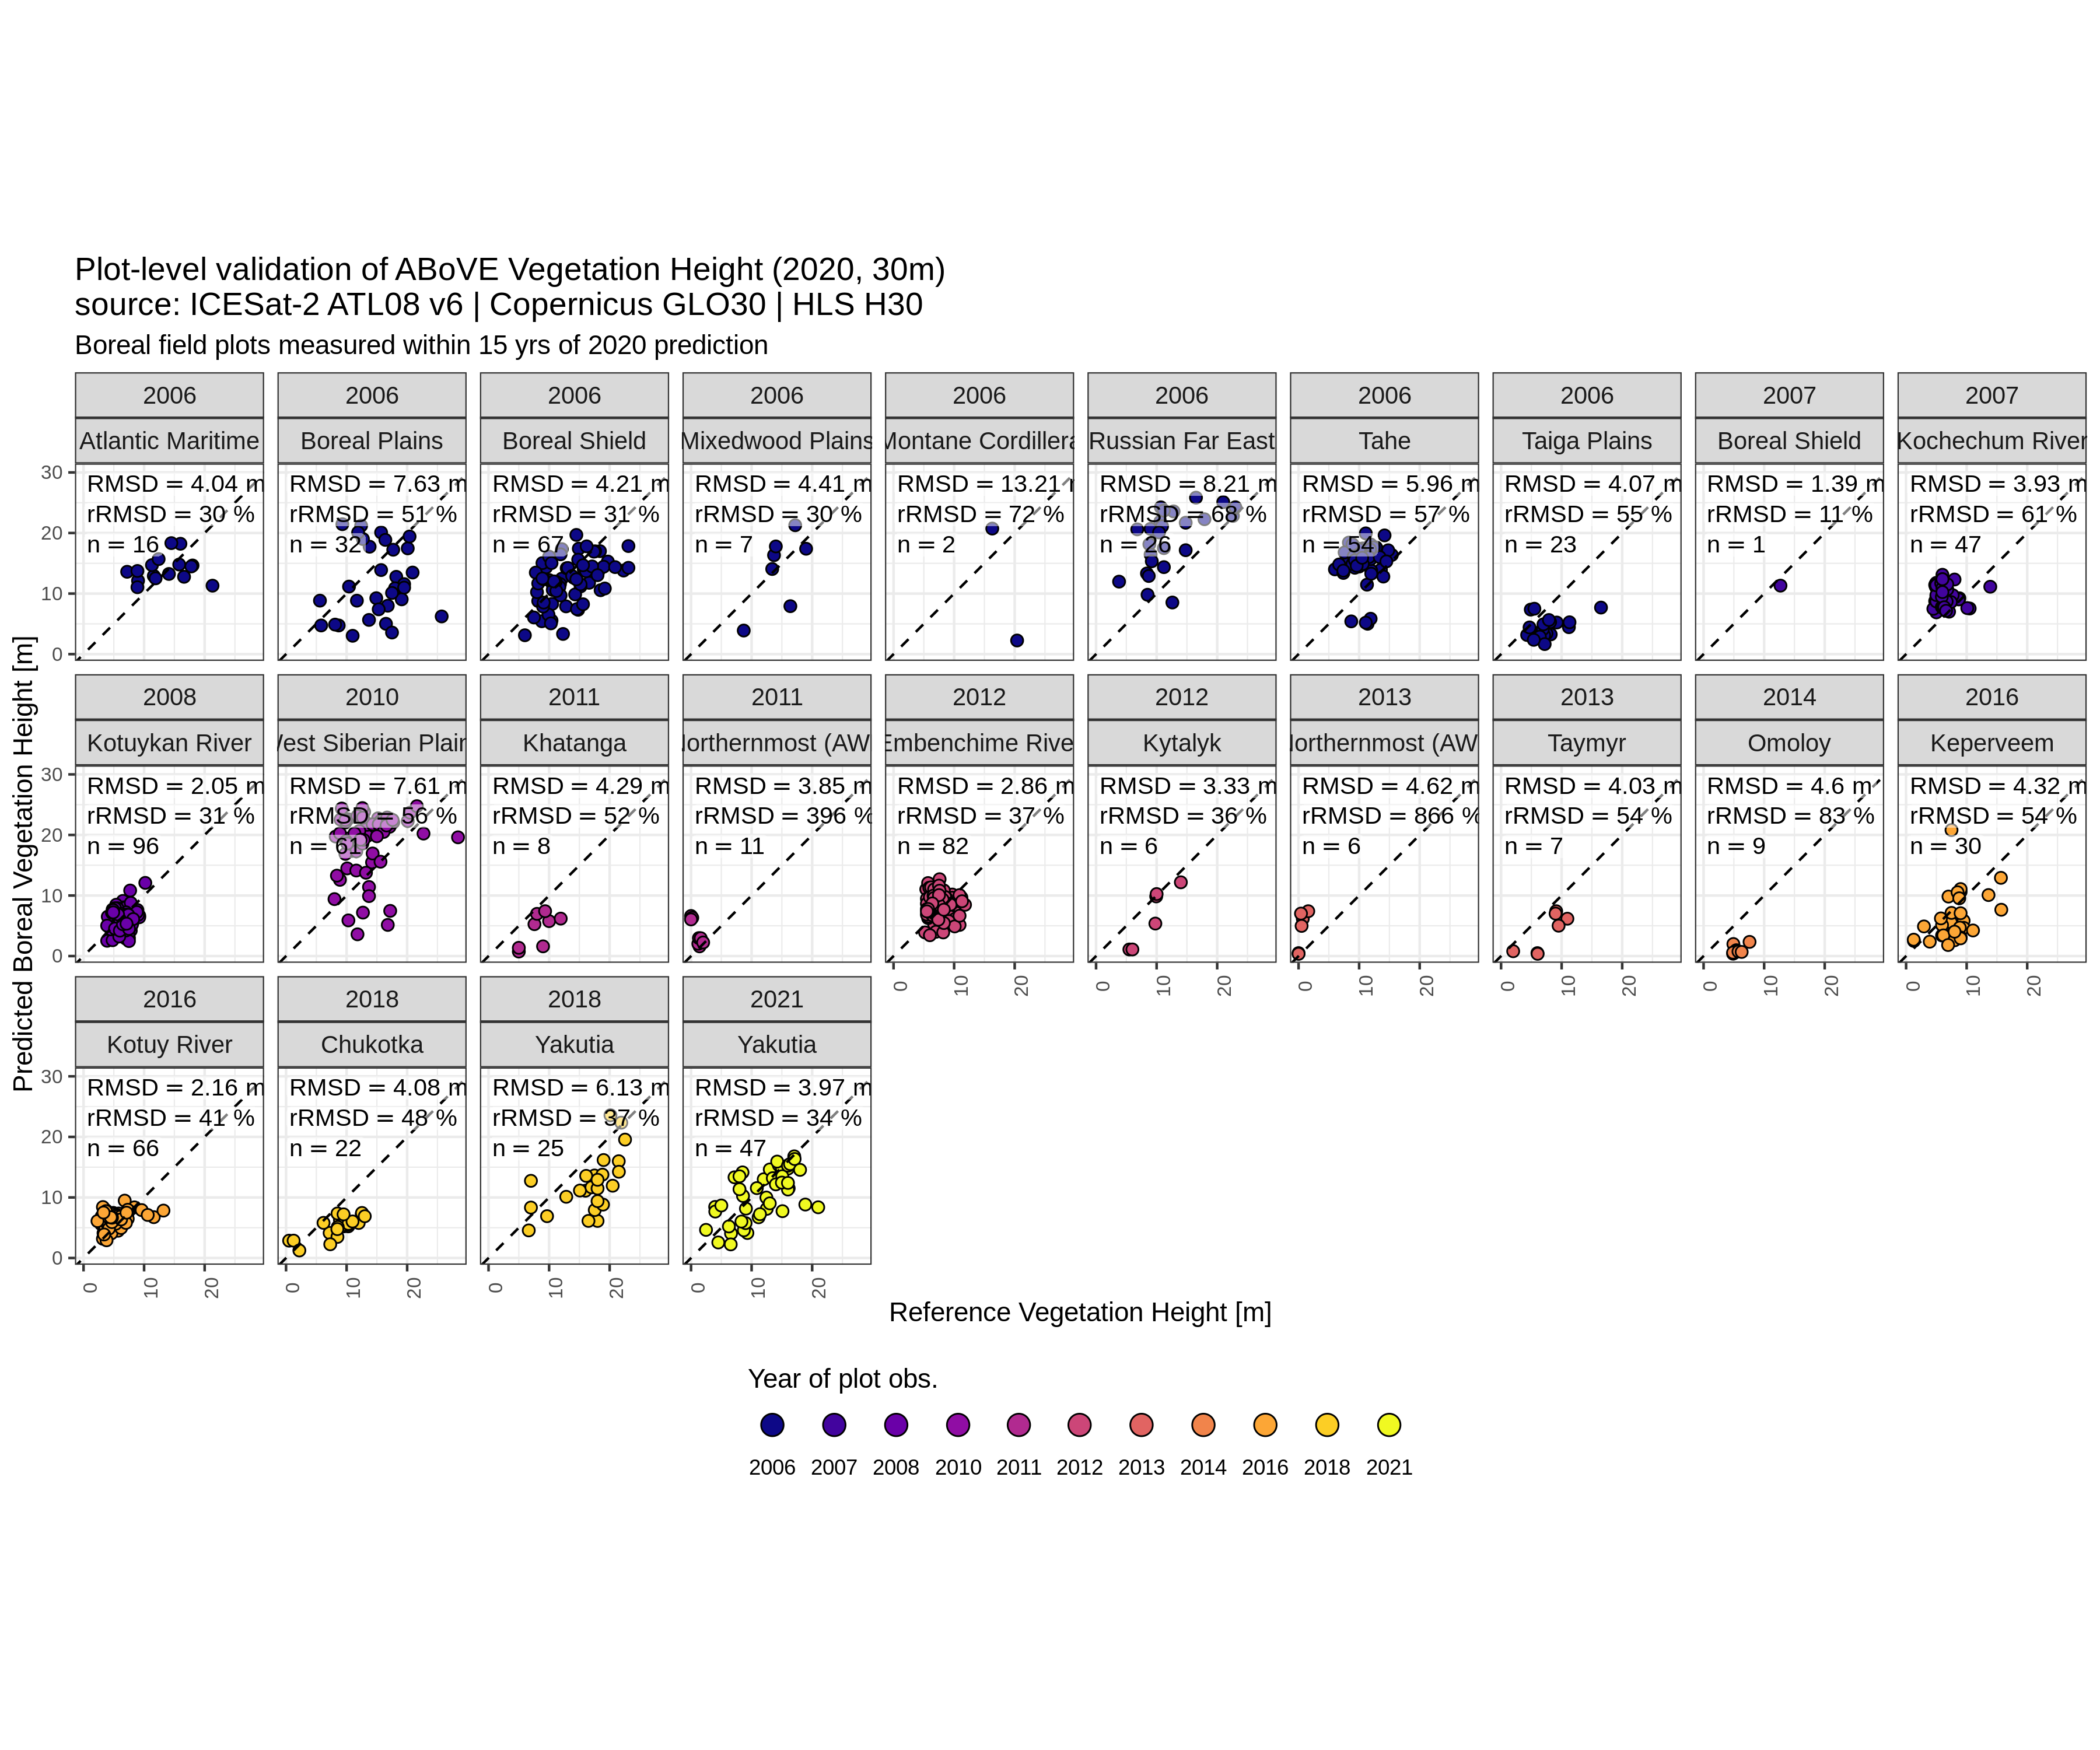

In [809]:
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 300)

htmax = 30

df_eq_region_group_FILT = df_eq_region_group %>% 
            filter(diff_yr < MAX_DIFF_YR) #%>% filter(continent == 'Eurasia')

p_scat = val_plots_df %>% 
    #filter(continent == 'Eurasia') %>% 
    filter(diff_yr < MAX_DIFF_YR) %>%
    #ggplot(aes(x=as.numeric(ref_ht), y=as.numeric(value_ht_H30_2020) )) + 
    ggplot(aes(x=as.numeric(ref_ht), y=.data[[VAL_TYPE]] )) + 
    geom_point(
        #aes(color=factor(value_esawc2020)), 
        aes(fill=factor(year)),
        size=2, shape=21, color='black') + 
    #scale_color_manual(values = c("#0072B2","#009E73","#D55E00")) +
    #scale_color_manual(values = col_pal, name='Land Cover Class') +
    #scale_fill_viridis_d(option='plasma', name='Difference (years) between observations\n[satellite-field]') +
    scale_fill_viridis_d(option='plasma', name='Year of plot obs.') +
    geom_abline(linetype='dashed') +
    coord_equal() +
    theme_bw() +
    theme(axis.text.x=element_text(angle=90, size=8), axis.text.y = element_text(size=8), strip.text = element_text(size=7)) + 
    labs(x='Reference Vegetation Height [m]', 
         #y = 'Predicted Boreal Forest Height (HLS L30 + Topo) [m]',
         y = 'Predicted Boreal Vegetation Height [m]',
         #title='Plot-level validation of ABoVE Boreal Forest Height (c2020 30m) from ICESat-2, Topography, & HLS L30', 
         title=paste0(TITLE_MAIN,' (',VAL_YEAR,', 30m)\nsource: ', VARS_RS), 
         subtitle=paste0('Boreal field plots measured within ', MAX_DIFF_YR, ' yrs of ',VAL_YEAR,' prediction')) +
    facet_wrap(year+group_name~., ncol=10)+
    #geom_label(data=df_eq, aes(x = 0.1, y = htmax,label=paste("r^2 ==", r2,sep='')), parse = TRUE, hjust="inward", vjust="inward", size=2, color = "black", fill="white", label.padding=unit(0.1,"lines"))+
    #geom_label(data=df_eq, aes(x = 0.1, y = htmax-3,label=paste("rmse ==", rmse,sep='')), parse = TRUE, hjust="inward", vjust="inward", size=2, color = "black", fill="white", label.padding=unit(0.1,"lines"))+
    #geom_label(data=df_eq, aes(x = 0.1, y = htmax-6,label=paste("bias ==", int,sep='')), parse = TRUE, hjust="inward", vjust="inward", size=2, color = "black", fill="white", label.padding=unit(0.1,"lines"))+
    #geom_label(data=df_eq, aes(x = 0.1, y = htmax-9,label=paste("slope ==", slope,sep='')),parse = TRUE, hjust="inward", vjust="inward", size=2, color = "black", fill="white", label.padding=unit(0.1,"lines")) +
    geom_label(data=df_eq_region_group_FILT #%>% filter(continent == 'Eurasia') 
               , aes(x = 0.1, y = htmax, label=paste("RMSD ==", round(rmsd, 2), "~m", sep=''), group=factor(year)), 
               parse = TRUE, hjust="inward", vjust="inward", size=3.5, color = "black", fill="white", alpha=0.5, label.size = NA, label.padding=unit(0.1,"lines")) +
    geom_label(data=df_eq_region_group_FILT #%>% filter(continent == 'Eurasia')
               , aes(x = 0.1, y = htmax-5, label=paste("rRMSD ==", round(rrmsd*100, 2), "~'%\'",  sep=''), group=factor(year)), 
               parse = TRUE, hjust="inward", vjust="inward", size=3.5, color = "black", fill="white", alpha=0.5, label.size = NA, label.padding=unit(0.1,"lines")) +
    geom_label(data=df_eq_region_group_FILT #%>% filter(continent == 'Eurasia')
               , aes(x = 0.1, y = htmax-10, label=paste("n ==", round(n, 2),  sep=''), group=factor(year)), 
               parse = TRUE, hjust="inward", vjust="inward", size=3.5, color = "black", fill="white", alpha=0.5, label.size = NA, label.padding=unit(0.1,"lines")) +
    guides(fill=guide_legend(override.aes = list(size = 4), title.position = "top", label.position = "bottom", legend.position='horizontal', nrow=1,
                                     #,keywidth = unit(.125, "cm"), keyheight = unit(1, "cm")
                                    )) +
    theme(legend.position='bottom', strip.text=element_text(size=10))
    #facet_wrap(.~interaction(factor(value_esawc2020), factor(year)), ncol=4)
    #facet_wrap(interaction(group_name, year)~.)

p_scat

### Look at height diffs

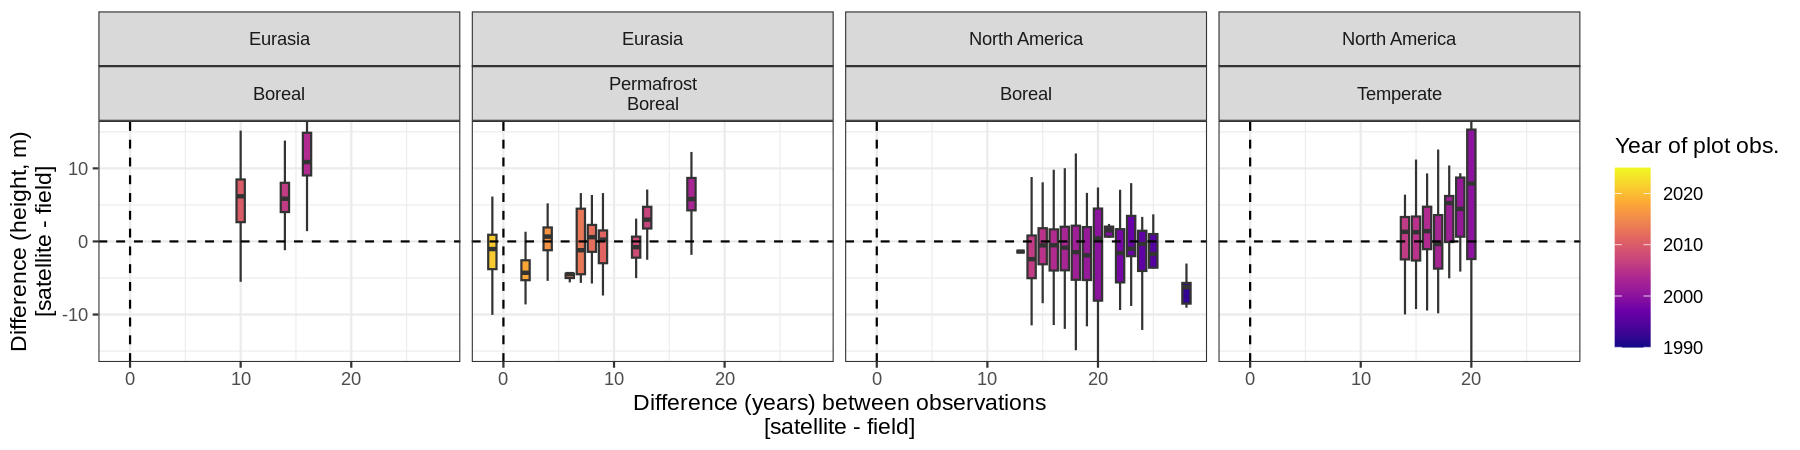

In [716]:
options(repr.plot.width = 12, repr.plot.height = 3, repr.plot.res = 150)

p_box_region = ggplot(val_plots_df) +
    geom_boxplot(aes(y=diff_ht, x=diff_yr, fill=as.numeric(year), group=year), outlier.size=-1) +
    geom_hline(aes(yintercept=0), linetype='dashed') +
    geom_vline(aes(xintercept=0), linetype='dashed') +

    #scale_fill_viridis_d(option='plasma', name='Years difference\n[satellite-field]', guide=FALSE) +
    #scale_fill_viridis_c(option='plasma', name='Year of plot obs.') +
    scale_fill_viridis_c(option='plasma', name='Year of plot obs.', limits = c(1990, 2025)) +
    coord_cartesian(ylim=c(-15,15)) +
    labs(y='Difference (height, m)\n[satellite - field]', x='Difference (years) between observations\n[satellite - field]')+
    theme_bw() +
    facet_wrap(continent+region ~ ., ncol=4)

p_box_region


In [717]:
val_plots_df %>%
    st_write(dsn = '/projects/my-private-bucket/reference/val_plots.gpkg', layer = 'val_plots', append=FALSE)

Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
“GDAL Error 4: sqlite3_open(/projects/my-private-bucket/reference/val_plots.gpkg) failed: unable to open database file”

Creating dataset /projects/my-private-bucket/reference/val_plots.gpkg failed.


ERROR: Error in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), : Creation failed.



In [ ]:
map_plots = maps_both 

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 12, repr.plot.res = 300)

# layout = "
# AAAAAABBBBB
# AAAAAABBBBB
# AAAAAACCCCD
# "

# figure = (p_scat_region + facet_wrap(continent~region, ncol=2))+
#     (map_plots + guides(fill="none") )+ p_box_region + p_rmse +
#     plot_layout(design = layout) +
#     plot_annotation(tag_levels = 'A',tag_prefix = '(', tag_sep = '', tag_suffix = ')') 

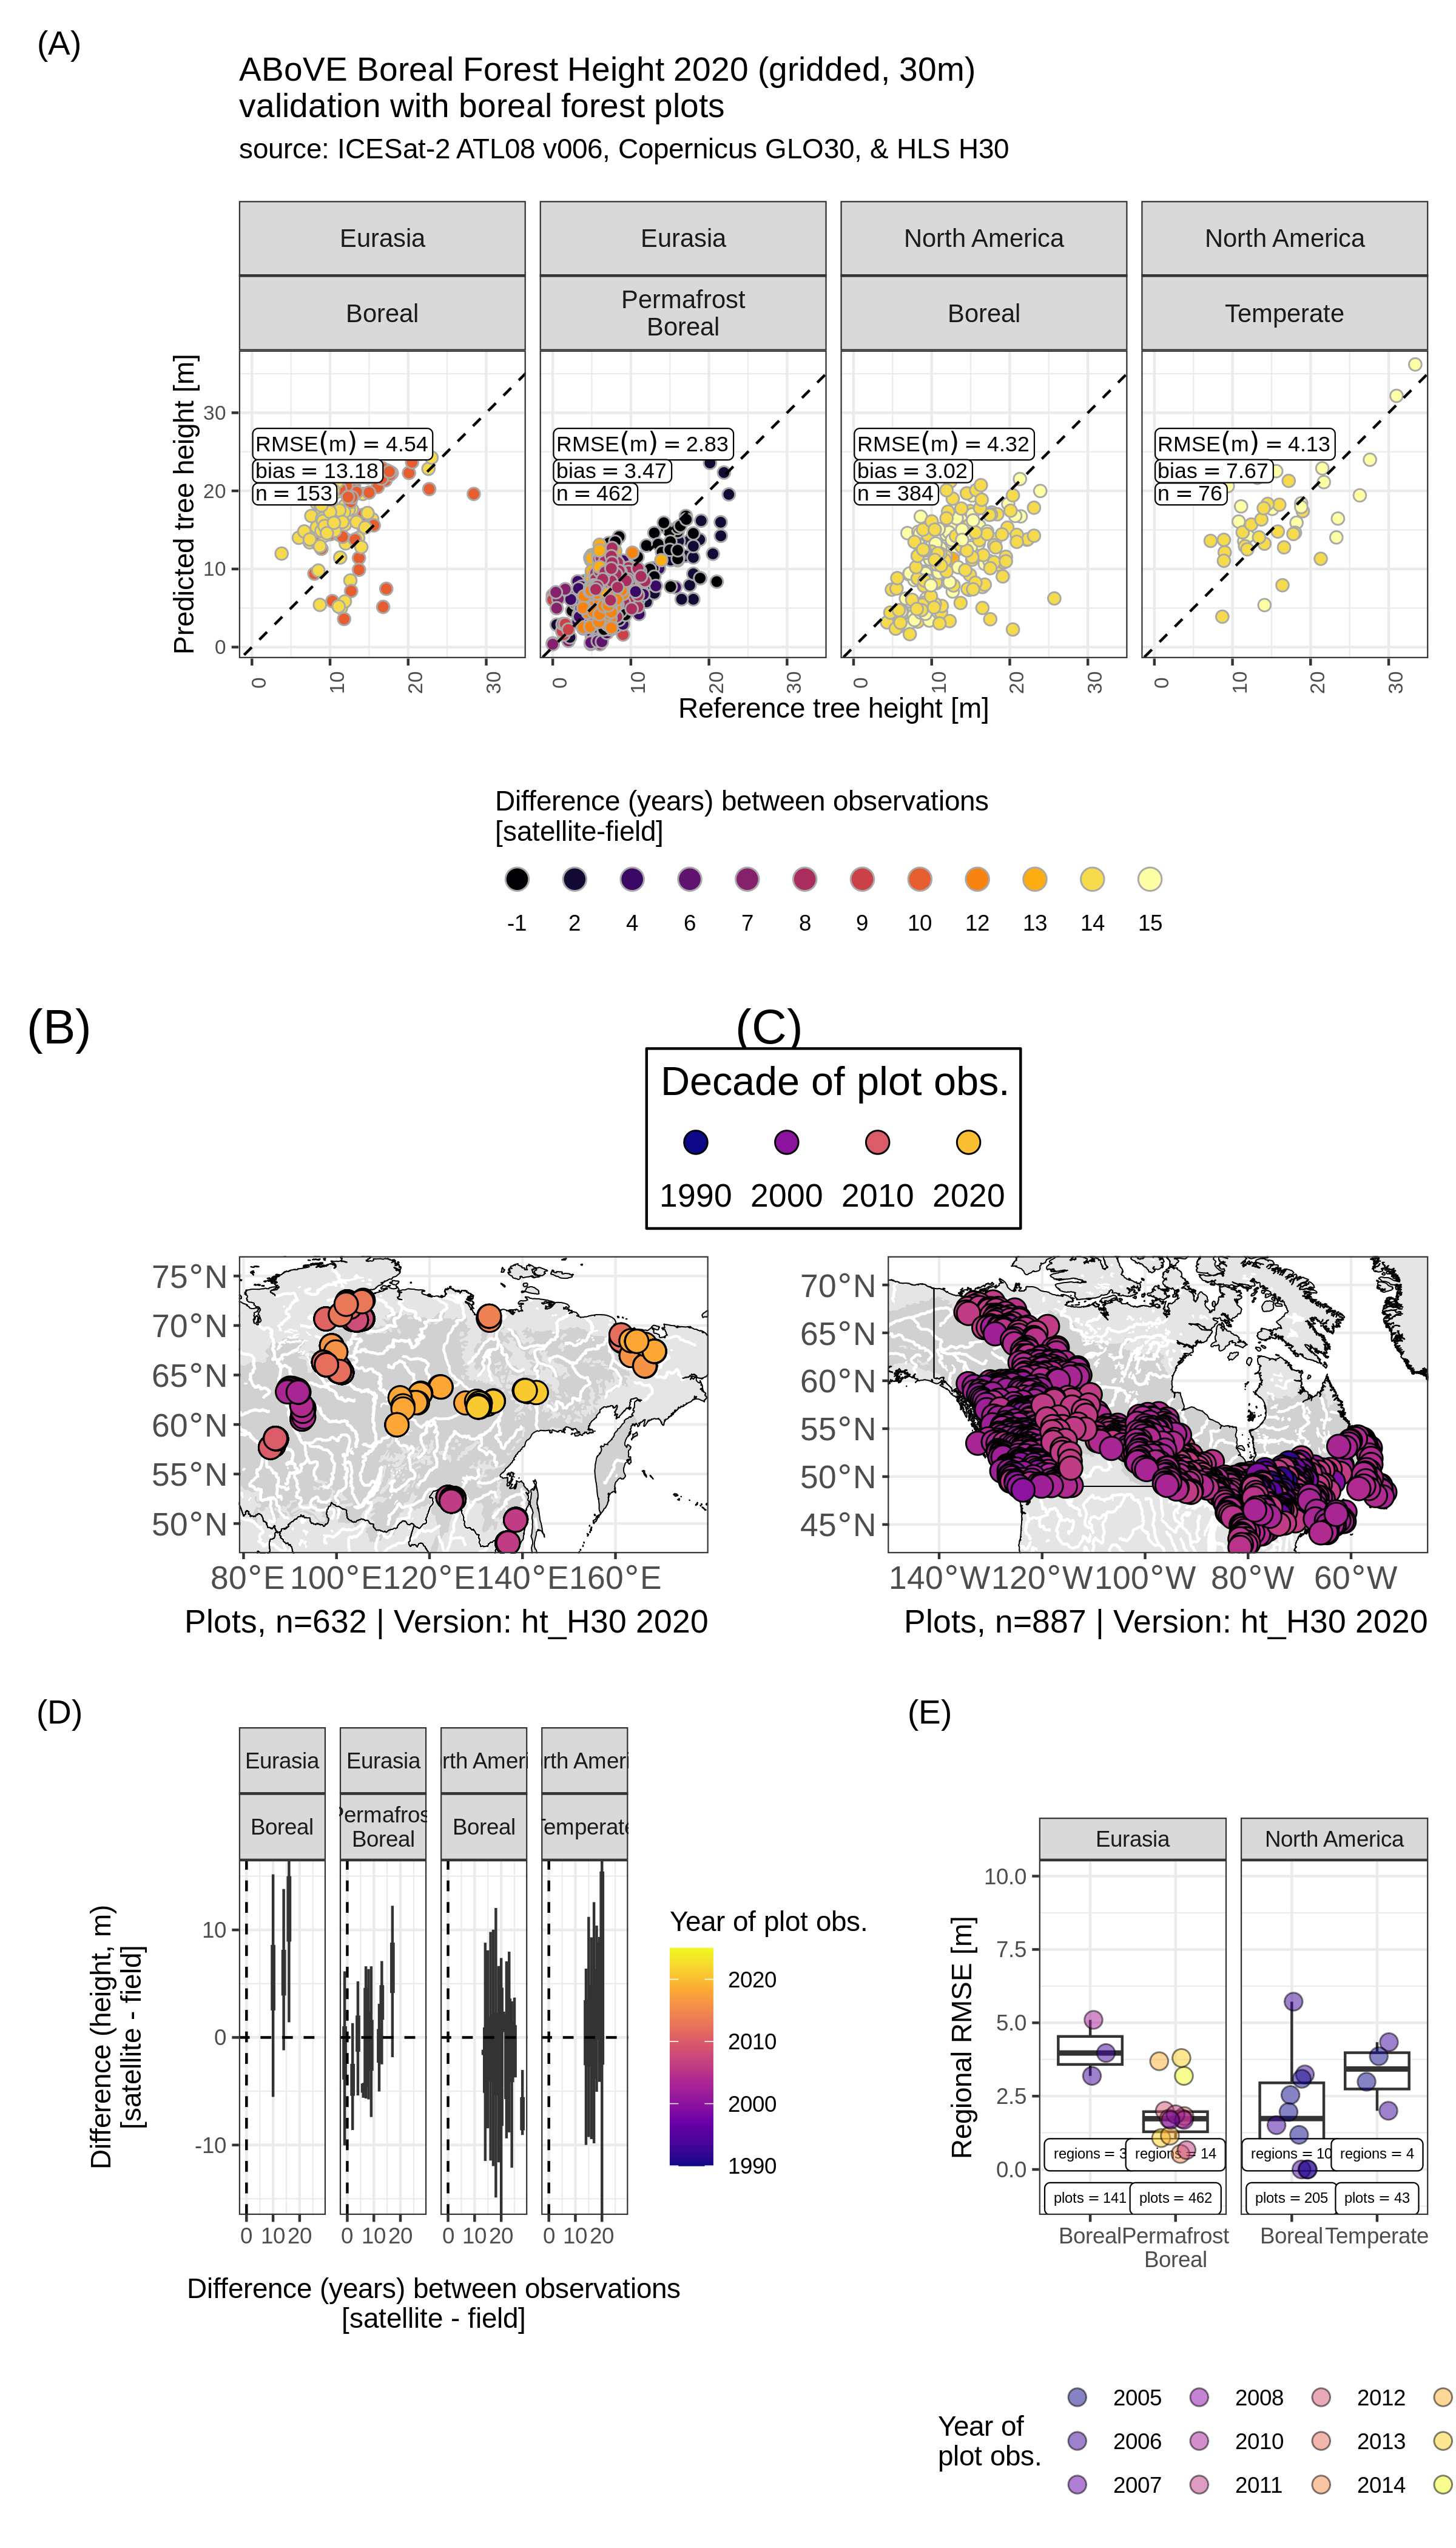

In [793]:
options(repr.plot.width = 8, repr.plot.height = 14, repr.plot.res = 300)

layout = "
AAAA
BBBB
CCDD
"

figure = (p_scat_region )+
    (map_plots + guides(fill="none") )+ p_box_region + p_rmse +
    plot_layout(design = layout) +
    plot_annotation(tag_levels = 'A',tag_prefix = '(', tag_sep = '', tag_suffix = ')') 

figure

In [221]:
# # Save
#   ggsave(plot = plot_lvis_gliht,
#            file = paste0(maindir,"//above_lidar_chk//", "plots_HT_validation_lvis_gliht_",ht_type,"_",facet_type,"_",RES,"m.png"), 
#          device = 'png', dpi = 300, width = 8, height = 5)

# Code:
from above_lidar_check.Rmd  

In [255]:
lm_eqn = function(df){
      y=df[,1]
      x=df[,2]
      m = lm(y ~ x, df);
      
      eq <- substitute(italic(y) == a + b %.% italic(x)*","~~italic(r)^2~"="~r2, 
           list(a = format(coef(m)[1], digits = 2), 
                b = format(coef(m)[2], digits = 2), 
               r2 = format(summary(m)$r.squared, digits = 3)))
      int = format(coef(m)[1], digits = 2)
      slope = format(coef(m)[2], digits = 2)
      # https://stackoverflow.com/questions/43123462/how-to-obtain-rmse-out-of-lm-result
      
      rss   <- c(crossprod(m$residuals))
      mse   <- rss / length(m$residuals)
    
      rmsd <- format(sqrt(mean((y-x)*(y-x))), dig=2)
      
      rmse  <- format(sqrt(mse),dig=2)
      sig2  <- format(rss / m$df.residual, dig=2) # Pearson estimated residual variance (as returned by summary.lm):
      n     <- nobs(m)
      r2    <- format(summary(m)$r.squared, dig = 2)
      mae   <- format(mean(abs(m$residuals)), dig = 2)
      mape  <- format(mean(abs((m$residuals)/y))*100, dig=2)  #https://stats.stackexchange.com/questions/299712/what-are-the-shortcomings-of-the-mean-absolute-percentage-error-mape

      #return(as.character(as.expression(eq)))
      return(data.frame(cbind(int, slope, r2, rmsd, rmse, sig2, n, mae, mape)))
  }
